# Simulation of expected reconstructed event distribution from effective area and reconstruction 

## Calculation of effective area ...and more as it seems

### Calculation of Aeff

In [1]:
import numpy as np
import h5py
from astropy.table import Table
import numpy as np
import pandas as pd
import numba as nb
from numba import jit, njit, prange, float64, int64
from km3pipe.math import azimuth, zenith
import astropy.coordinates as ac
from astropy.time import Time
import astropy.units as u


def aeff_2D_eventlist(e_bins, t_bins, eventlist, gamma, n_runs, method=1):
    """
    Calculate the effective area in energy and zenith angle bins.

    Parameters
    ----------
    e_bins : Array
        of energy bins in GeV
    t_bins : Array
        of zenith angle bins in rad
    dataset : pandas.DataFrame
        with the events
    gamma : float, default 1.4
        spectral index of simulated events
    nevents : float, default 2e7
        number of generated events

    Returns
    -------
    2D-Array
        with the effective area in m^2 binned in energy and zenith angle bins

    """

    #if mcversion >= 9.0: T = 1.0
    #else: T = 365.25 * 24 *3600
        
    cos_theta = np.cos(eventlist["theta_mc"])
    theta_bins = np.searchsorted(t_bins, cos_theta) - 1

    #theta_bins = np.searchsorted(t_bins, eventlist['theta_mc']) - 1
    energy_bins = np.searchsorted(e_bins, eventlist['energy_mc']) - 1

    w2 = np.array(eventlist['normalized_weight'].value)
    E = np.array(eventlist['energy_mc'].value)
    
    if method == 1: aeff = fill_aeff_2D(e_bins, t_bins, energy_bins, theta_bins, w2, E, gamma)/n_runs
    elif method == 2: aeff = fill_aeff_2D_method2(e_bins, t_bins, energy_bins, theta_bins, w2, E)/n_runs
    else:
        raise ValueError("Unknown method. Choose method=1 or method=2.")
    return aeff


@njit(fastmath=False, parallel=True)
def fill_aeff_2D(e_bins, t_bins, energy_bins, theta_bins, w2, E, gamma):
    """
    numba accelerated helper function to calculate effective area.

    """
    #T = 365.25 * 24 * 3600
    #T = 1.0
    aeff = np.empty((len(e_bins) - 1, len(t_bins) - 1))
    for k in prange(len(e_bins) - 1):
        for i in range(len(t_bins) - 1):
            mask = (energy_bins == k) & (theta_bins == i)
            #d_omega = -(np.cos(t_bins[i + 1]) - np.cos(t_bins[i]))
            d_omega = (t_bins[i + 1] - t_bins[i])
            d_E = (e_bins[k + 1]) ** (1 - gamma) - (e_bins[k]) ** (1 - gamma)
            aeff[k, i] = (
                (1 - gamma)
                * np.sum(E[mask] ** (-gamma) * w2[mask])
                / (d_omega * d_E * 2 * np.pi)
            )

    return aeff


@njit(fastmath=False, parallel=True)
def fill_aeff_2D_method2(e_bins, t_bins, energy_bins, theta_bins, w2, E):
    """
    numba accelerated helper function to calculate effective area.

    """
    
    aeff = np.empty((len(e_bins) - 1, len(t_bins) - 1))
    for k in prange(len(e_bins) - 1):
        for i in range(len(t_bins) - 1):
            mask = (energy_bins == k) & (theta_bins == i)
            
            d_E = np.log10(e_bins[k + 1]/e_bins[k])
            d_Omega = 4 * np.pi/len(t_bins)
            #d_Omega = 2 * np.pi * (t_bins[i + 1] - t_bins[i])
            aeff[k, i] = (
                np.sum(E[mask] ** (-1) * w2[mask])
                / (np.log(10) * d_E * d_Omega)
            )

    return aeff


print("Functions built.")

def create_aeff_file_from_eventlist(config, output_path, E_min, E_max, gamma=1.4, method=1):
    """
    Computes and saves the 2D and 1D effective area for one or more neutrino flavors.

    Parameters
    ----------
    config : dict
        Dictionary with flavor-specific settings. Example:
        {
            "input_file": "/path/to/input.hdf5",
            "flavors": {
                "numu": {
                    "pdg_id": 14,
                    "nruns": 518,
                },
                "anue": {
                    "pdg_id": -12,
                    "nruns": 518,
                }
            }
        }
    output_path : str
        Path to save the resulting HDF5 file.
    gamma : float
        Spectral index of the simulated spectrum.
    method : int
        Method for computing the effective area (1 or 2).
    """

    #from your_module import aeff_2D_eventlist  # Replace with correct import

    print(f"Loading events from: {config['input_file']}")
    with h5py.File(config["input_file"], 'r') as h5_file:
        event_table = Table.read(h5_file)

    # Define binning
    #E_min, E_max = 1e2, 1e8
    n_energy_bins, n_theta_bins = 100, 100
    energy_bins = np.logspace(np.log10(E_min), np.log10(E_max), n_energy_bins + 1)
    cos_theta_bins = np.linspace(-1.0, 1.0, n_theta_bins + 1)
    dcos = np.diff(cos_theta_bins)

    # Output structure
    with h5py.File(output_path, "w") as f:
        f.create_dataset("energy_bins", data=energy_bins)
        f.create_dataset("cos_theta_bins", data=cos_theta_bins)
        f.attrs["gamma"] = gamma
        f.attrs["method"] = method

        for flavor, info in config["flavors"].items():
            print(f"Processing flavor: {flavor}")

            # Select events
            pdg_id = info["pdg_id"]
            nruns = info["nruns"]
            flavor_events = event_table[event_table["pdg_id"] == pdg_id]

            # Compute effective areas
            aeff_2d = aeff_2D_eventlist(
                energy_bins,
                cos_theta_bins,
                flavor_events,
                gamma=gamma,
                n_runs=nruns,
                method=method
            )

            aeff_1d = np.sum(aeff_2d * dcos[np.newaxis, :] * 0.5, axis=1)

            # Store in HDF5
            grp = f.create_group(flavor)
            grp.create_dataset("aeff_2d", data=aeff_2d)
            grp.create_dataset("aeff_1d", data=aeff_1d)
            grp.attrs["pdg_id"] = pdg_id
            grp.attrs["nruns"] = nruns

    print(f"Saved A_eff data to {output_path}")



/home/hpc/capn/capn107h/software/km3astrovenv3.9.12/lib64/python3.9/site-packages/km3pipe/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Functions built.


In [2]:
config = {
    "input_file": "/home/wecapstor3/capn/capn107h/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4983084events_mc.hdf5",
    "flavors": {
        "numu": {
            "pdg_id": 14,
            "nruns": 518
        },
        "anumu": {
            "pdg_id": -14,
            "nruns": 518
        },
        "anue": {
            "pdg_id": -12,
            "nruns": 518
        },
        "nue": {
            "pdg_id": 12,
            "nruns": 518
        },
        "nutau": {
            "pdg_id": 16,
            "nruns": 518
        },
        "anutau": {
            "pdg_id": -16,
            "nruns": 518
        }
    }
}

output_path = "aeff_summary_v9_flavors_arca.hdf5"
create_aeff_file_from_eventlist(config, output_path, 1e2, 1e8, gamma=1.4)

Loading events from: /home/wecapstor3/capn/capn107h/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4983084events_mc.hdf5
Processing flavor: numu
Processing flavor: anumu
Processing flavor: anue
Processing flavor: nue
Processing flavor: nutau
Processing flavor: anutau
Saved A_eff data to aeff_summary_v9_flavors_arca.hdf5


In [3]:
config = {
    "input_file": "/home/wecapstor3/capn/capn107h/combined_eventlists/orca_KM3NeT_00000148_0001_combined_1008510events_mc.hdf5",
    "flavors": {
        "numu": {
            "pdg_id": 14,
            "nruns": 481
        },
        "anumu": {
            "pdg_id": -14,
            "nruns": 481
        },
        "anue": {
            "pdg_id": -12,
            "nruns": 481
        },
        "nue": {
            "pdg_id": 12,
            "nruns": 481
        },
        "nutau": {
            "pdg_id": 16,
            "nruns": 481
        },
        "anutau": {
            "pdg_id": -16,
            "nruns": 481
        }
    }
}

output_path = "aeff_summary_v9_flavors_orca.hdf5"
create_aeff_file_from_eventlist(config, output_path, 1e-1, 1e4, gamma=1.4)

Loading events from: /home/wecapstor3/capn/capn107h/combined_eventlists/orca_KM3NeT_00000148_0001_combined_1008510events_mc.hdf5
Processing flavor: numu
Processing flavor: anumu
Processing flavor: anue
Processing flavor: nue
Processing flavor: nutau
Processing flavor: anutau
Saved A_eff data to aeff_summary_v9_flavors_orca.hdf5


In [4]:
def load_aeff_multi(file_path, flavors):
    """Load effective area data for multiple neutrino flavors.

    Parameters
    ----------
    file_path : str
        Path to the HDF5 file with A_eff data.
    flavors : list of str
        List of flavor keys to load.

    Returns
    -------
    dict
        Dictionary with each flavor as a key, and values being a dict with
        'aeff_1d', 'aeff_2d', 'energy_bins', 'cos_theta_bins' and optional metadata.
    """
    data = {}
    with h5py.File(file_path, 'r') as f:
        energy_bins = f['energy_bins'][()]
        cos_theta_bins = f['cos_theta_bins'][()]
        gamma = f.attrs.get('gamma', None)
        method = f.attrs.get('method', None)

        for flavor in flavors:
            if flavor in f:
                grp = f[flavor]
                data[flavor] = {
                    "aeff_1d": grp['aeff_1d'][()],
                    "aeff_2d": grp['aeff_2d'][()],
                    "energy_bins": energy_bins,
                    "cos_theta_bins": cos_theta_bins,
                    "pdg_id": grp.attrs.get("pdg_id", None),
                    "nruns": grp.attrs.get("nruns", None),
                    "gamma": gamma,
                    "method": method,
                }
            else:
                print(f"Warning: Flavor '{flavor}' not found in file.")
    return data


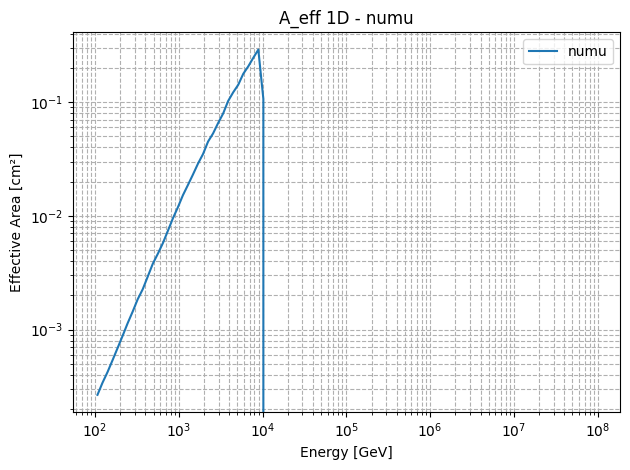

In [5]:
flavor_list = ["numu", "anumu", "nue", "anue","nutau", "anutau"]
aeff_data = load_aeff_multi("aeff_summary_v9_flavors.hdf5", flavor_list)

# Access individual flavor data
flavor = "numu"
aeff_1d = aeff_data[flavor]["aeff_1d"]
energy_bins = aeff_data[flavor]["energy_bins"]

# Optional: plot it
import matplotlib.pyplot as plt
import numpy as np

energy_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
plt.loglog(energy_centers, aeff_1d, label=flavor)
plt.xlabel("Energy [GeV]")
plt.ylabel("Effective Area [cm²]")
plt.title(f"A_eff 1D - {flavor}")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.tight_layout()
plt.show()


### Calculation of Reconstruction Response

In [6]:
import numpy as np
from h5py import File
from astropy.table import Table
import os

def create_energy_histogram(input_file, output_file, pdgid = [14], bins_true=None, bins_reco=None):
    # Load the event data
    with File(input_file, 'r') as h5_file:
        EventList = Table.read(h5_file)
        #pdgmask = (EventList['pdg_id'] == pdgid)
        pdgmask = np.isin(EventList['pdg_id'], pdgid)
        E_mc = EventList[pdgmask]['energy_mc']
        E_reco = EventList[pdgmask]['energy']
        
        

    # Clean the data
    valid_mask = (
        ~np.isnan(E_mc) & 
        ~np.isnan(E_reco) & 
        (E_mc > 0) & 
        (E_reco > 0)
    )
    E_mc_clean = E_mc[valid_mask]
    E_reco_clean = E_reco[valid_mask]

    # Use default binning if not provided
    if bins_true is None:
        bins_true = np.logspace(2, 8, 100)
    if bins_reco is None:
        bins_reco = np.logspace(2, 8, 100)

    # Create the 2D histogram
    hist2d, xedges, yedges = np.histogram2d(E_mc_clean, E_reco_clean, bins=[bins_true, bins_reco])

    pdg_str = "_".join(str(pid) for pid in pdgid)
    output_hdf5_file = output_file + "pdgid" + pdg_str + ".hdf5"

    # Save histogram and bin edges to HDF5
    with File(output_hdf5_file, 'w') as f_out:
        f_out.create_dataset("hist2d", data=hist2d)
        f_out.create_dataset("bins_true", data=xedges)
        f_out.create_dataset("bins_reco", data=yedges)

    print(f"Saved histogram to: {output_hdf5_file}")

input_file_arca  ="/home/wecapstor3/capn/capn107h/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4983084events_mc.hdf5"
input_file_orca = "/home/wecapstor3/capn/capn107h/combined_eventlists/orca_KM3NeT_00000148_0001_combined_1008510events_mc.hdf5"
output_file_arca = "arca_energy_response_histogram"
output_file_orca = "orca_energy_response_histogram"
create_energy_histogram(input_file_arca, output_file_arca + "_shower_", pdgid=[12,-12,16,-16])
create_energy_histogram(input_file_arca, output_file_arca + "_track_", pdgid=[14,-14])
create_energy_histogram(input_file_orca, output_file_orca + "_shower_", pdgid=[12,-12,16,-16])
create_energy_histogram(input_file_orca, output_file_orca + "_track_", pdgid=[14,-14])


Saved histogram to: arca_energy_response_histogram_shower_pdgid12_-12_16_-16.hdf5
Saved histogram to: arca_energy_response_histogram_track_pdgid14_-14.hdf5
Saved histogram to: orca_energy_response_histogram_shower_pdgid12_-12_16_-16.hdf5
Saved histogram to: orca_energy_response_histogram_track_pdgid14_-14.hdf5


In [85]:
import numpy as np
from h5py import File
from astropy.table import Table
import matplotlib.pyplot as plt

def create_energy_histogram(input_file, output_file_prefix, pdgid=[14], bins_true=None, bins_reco=None):
    """Create and save a 2D histogram of true vs. reco energies for specified PDG IDs."""
    with File(input_file, 'r') as h5_file:
        EventList = Table.read(h5_file)
        pdgmask = np.isin(EventList['pdg_id'], pdgid)
        E_mc = EventList[pdgmask]['energy_mc']
        E_reco = EventList[pdgmask]['energy']

    valid_mask = (~np.isnan(E_mc) & ~np.isnan(E_reco) & (E_mc > 0) & (E_reco > 0))
    E_mc_clean = E_mc[valid_mask]
    E_reco_clean = E_reco[valid_mask]

    if bins_true is None:
        bins_true = np.logspace(2, 8, 100)
    if bins_reco is None:
        bins_reco = np.logspace(2, 8, 100)

    hist2d, xedges, yedges = np.histogram2d(E_mc_clean, E_reco_clean, bins=[bins_true, bins_reco])

    pdg_str = "_".join(str(pid) for pid in pdgid)
    output_file = f"{output_file_prefix}pdgid{pdg_str}.hdf5"
    with File(output_file, 'w') as f_out:
        f_out.create_dataset("hist2d", data=hist2d)
        f_out.create_dataset("bins_true", data=xedges)
        f_out.create_dataset("bins_reco", data=yedges)

    print(f"Saved histogram to: {output_file}")
    return output_file  # return filename for convenience


def plot_energy_response_histogram(hist_file, sampled_true_energy=None):
    """Load a saved 2D histogram and plot true vs reco energy with optional sampled PDF."""
    with File(hist_file, 'r') as f:
        hist2d = f['hist2d'][()]
        bins_true = f['bins_true'][()]
        bins_reco = f['bins_reco'][()]

    plt.figure(figsize=(6, 5))
    plt.pcolormesh(bins_true, bins_reco, hist2d.T, norm=plt.matplotlib.colors.LogNorm(), shading='auto')

    E_min, E_max = bins_true[0], bins_true[-1]
    plt.plot([E_min, E_max], [E_min, E_max], 'k--', label=r'$E_{true} = E_{reco}$')

    if sampled_true_energy is not None:
        plt.axvline(sampled_true_energy, color='darkorange', lw=3, alpha=0.5, label=f"Sampled $E_{{true}}$ = {sampled_true_energy:.1e} GeV")

    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(E_min, E_max)
    plt.ylim(E_min, E_max)
    plt.xlabel(r"True Energy $E_{true}$ (GeV)")
    plt.ylabel(r"Reconstructed Energy $E_{reco}$ (GeV)")
    plt.title("True vs. Reconstructed Energy")
    plt.colorbar(label='Counts')
    plt.legend()
    plt.tight_layout()
    plt.show()


def sample_reco_energy(true_energy, hist2d, bins_true, bins_reco):
    """Sample reconstructed energy from the histogram given a true energy."""
    true_bin_idx = np.digitize(true_energy, bins_true) - 1
    if true_bin_idx < 0 or true_bin_idx >= hist2d.shape[0]:
        raise ValueError(f"True energy {true_energy} outside histogram range.")

    slice_hist = hist2d[true_bin_idx, :]
    pdf = slice_hist / np.sum(slice_hist) if np.sum(slice_hist) > 0 else np.zeros_like(slice_hist)
    bin_centers_reco = 0.5 * (bins_reco[:-1] + bins_reco[1:])

    if np.sum(pdf) == 0:
        print(f"Warning: No entries for true energy bin at {true_energy:.2e} GeV.")
        return None, None, None

    sampled_energy = np.random.choice(bin_centers_reco, p=pdf)
    return sampled_energy, pdf, bin_centers_reco


def plot_reco_pdf(sampled_energy, pdf, reco_centers, true_energy):
    """Plot the PDF of reco energies for a given true energy, with the sampled value."""
    if sampled_energy is None:
        print("No sampled energy to plot.")
        return

    plt.figure(figsize=(8, 4))
    plt.plot(reco_centers, pdf, drawstyle='steps-mid', color="darkorange", label='Reco PDF')
    #plt.axvline(sampled_energy, color='darkblue', linestyle='--', label=f'Sampled: {sampled_energy:.2e} GeV')
    plt.xscale('log')
    plt.xlabel(r"Reconstructed Energy $E_{reco}$ (GeV)")
    plt.ylabel("Probability Density")
    plt.title(f"Reco Energy PDF for True Energy {true_energy:.2e} GeV")
    plt.legend()
    plt.tight_layout()
    plt.show()


Saved histogram to: arca_energy_response_histogram_shower_pdgid12_-12_16_-16.hdf5
Saved histogram to: arca_energy_response_histogram_track_pdgid14_-14.hdf5


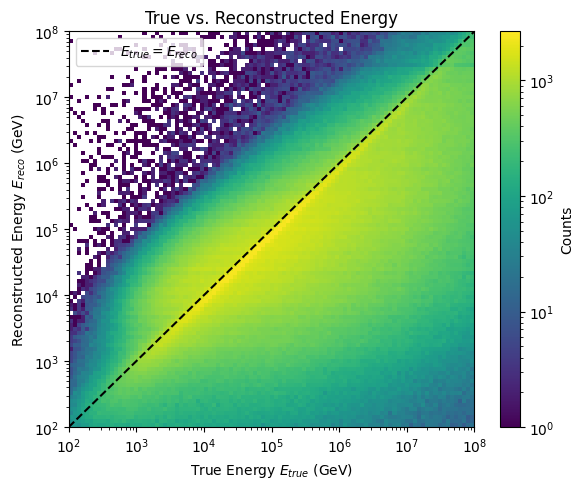

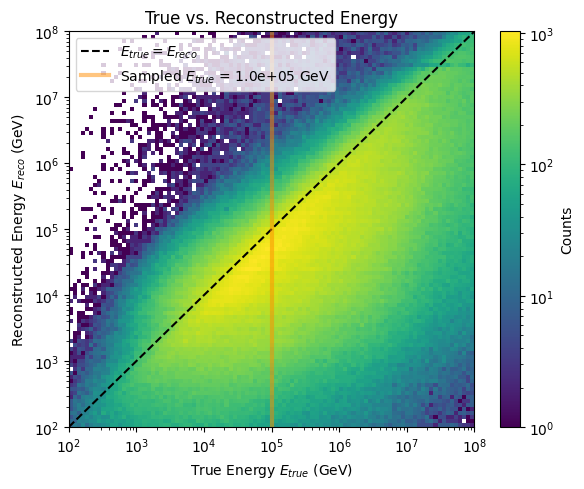

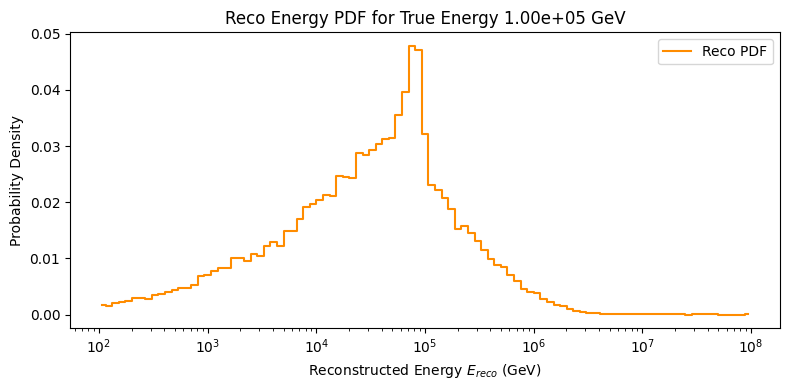

In [86]:
# Create histograms for showers and tracks (example):
output_file_shower = create_energy_histogram(input_file_arca, "arca_energy_response_histogram_shower_", pdgid=[12, -12, 16, -16])
output_file_track = create_energy_histogram(input_file_arca, "arca_energy_response_histogram_track_", pdgid=[14, -14])

# Plot the 2D histograms:
plot_energy_response_histogram(output_file_shower)
plot_energy_response_histogram(output_file_track, sampled_true_energy=1e5)

# Load histogram to sample reco energies
with File(output_file_shower, 'r') as f:
    hist2d = f['hist2d'][()]
    bins_true = f['bins_true'][()]
    bins_reco = f['bins_reco'][()]

true_energy = 1e5  # GeV
sampled_energy, pdf, reco_centers = sample_reco_energy(true_energy, hist2d, bins_true, bins_reco)

# Plot the PDF
plot_reco_pdf(sampled_energy, pdf, reco_centers, true_energy)


In [87]:
import numpy as np
from h5py import File
from astropy.table import Table
import matplotlib.pyplot as plt
import os

def create_energy_histogram(input_file, output_file_prefix, pdgid=[14], bins_true=None, bins_reco=None):
    """Create and save a 2D histogram of true vs. reco energies for specified PDG IDs."""
    with File(input_file, 'r') as h5_file:
        EventList = Table.read(h5_file)
        pdgmask = np.isin(EventList['pdg_id'], pdgid)
        E_mc = EventList[pdgmask]['energy_mc']
        E_reco = EventList[pdgmask]['energy']

    valid_mask = (~np.isnan(E_mc) & ~np.isnan(E_reco) & (E_mc > 0) & (E_reco > 0))
    E_mc_clean = E_mc[valid_mask]
    E_reco_clean = E_reco[valid_mask]

    if bins_true is None:
        bins_true = np.logspace(2, 8, 100)
    if bins_reco is None:
        bins_reco = np.logspace(2, 8, 100)

    hist2d, xedges, yedges = np.histogram2d(E_mc_clean, E_reco_clean, bins=[bins_true, bins_reco])

    pdg_str = "_".join(str(pid) for pid in pdgid)
    output_file = f"{output_file_prefix}pdgid{pdg_str}.hdf5"
    with File(output_file, 'w') as f_out:
        f_out.create_dataset("hist2d", data=hist2d)
        f_out.create_dataset("bins_true", data=xedges)
        f_out.create_dataset("bins_reco", data=yedges)

    print(f"Saved histogram to: {output_file}")
    return output_file


def plot_energy_response_histogram(hist_file, sampled_true_energy=None):
    """Load a saved 2D histogram and plot true vs reco energy with optional sampled PDF."""
    with File(hist_file, 'r') as f:
        hist2d = f['hist2d'][()]
        bins_true = f['bins_true'][()]
        bins_reco = f['bins_reco'][()]

    plt.figure(figsize=(7, 5))
    plt.pcolormesh(bins_true, bins_reco, hist2d.T, norm=plt.matplotlib.colors.LogNorm(), shading='auto')

    E_min, E_max = bins_true[0], bins_true[-1]
    plt.plot([E_min, E_max], [E_min, E_max], 'k--', label=r'$E_{true} = E_{reco}$')

    if sampled_true_energy is not None:
        plt.axvline(sampled_true_energy, color='darkorange', lw=3, alpha=0.5, label=f"Sampled $E_{{true}}$ = {sampled_true_energy:.1e} GeV")

    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(E_min, E_max)
    plt.ylim(E_min, E_max)
    plt.xlabel(r"True Energy $E_{true}$ (GeV)")
    plt.ylabel(r"Reconstructed Energy $E_{reco}$ (GeV)")
    plt.title("True vs. Reconstructed Energy")
    plt.colorbar(label='Counts')
    plt.legend()
    plt.tight_layout()
    plt.show()


def sample_reco_energy(true_energy, hist2d, bins_true, bins_reco):
    """Sample reconstructed energy from the histogram given a true energy."""
    true_bin_idx = np.digitize(true_energy, bins_true) - 1
    if true_bin_idx < 0 or true_bin_idx >= hist2d.shape[0]:
        raise ValueError(f"True energy {true_energy} outside histogram range.")

    slice_hist = hist2d[true_bin_idx, :]
    pdf = slice_hist / np.sum(slice_hist) if np.sum(slice_hist) > 0 else np.zeros_like(slice_hist)
    bin_centers_reco = 0.5 * (bins_reco[:-1] + bins_reco[1:])

    if np.sum(pdf) == 0:
        print(f"Warning: No entries for true energy bin at {true_energy:.2e} GeV.")
        return None, None, None

    sampled_energy = np.random.choice(bin_centers_reco, p=pdf)
    return sampled_energy, pdf, bin_centers_reco


def plot_reco_pdf(sampled_energy, pdf, reco_centers, true_energy, detectorname, pdgid, save_path):
    """Plot the PDF of reco energies for a given true energy, with the sampled value, save plot to file."""
    if sampled_energy is None:
        print("No sampled energy to plot.")
        return

    event_type = "track" if set(pdgid) == {14, -14} else "shower" if set(pdgid) == {12, -12, 16, -16} else "other"

    plt.figure(figsize=(8, 4))
    plt.plot(reco_centers, pdf, drawstyle='steps-mid', color="darkorange", label='Reco PDF')
    plt.axvline(sampled_energy, color='darkblue', linestyle='--', label=f'Sampled: {sampled_energy:.2e} GeV')
    plt.xscale('log')
    plt.xlabel(r"Reconstructed Energy $E_{reco}$ (GeV)")
    plt.ylabel("Probability Density")
    plt.title(f"{detectorname.upper()} {event_type.capitalize()} Reco Energy PDF\nTrue Energy = {true_energy:.2e} GeV, PDGIDs = {pdgid}")
    plt.legend()
    plt.tight_layout()

    # Save plot file
    fname = f"{detectorname}_{event_type}_reco_pdf_trueE{int(true_energy)}GeV.png"
    full_path = os.path.join(save_path, fname)
    plt.savefig(full_path)
    plt.close()
    print(f"Saved reco PDF plot to: {full_path}")


def generate_all_plots(detectorname, input_file, output_file_prefix, pdgid_list, sampled_true_energy, save_path="."):
    """Create histograms and reco energy PDFs for all PDGID sets for a given detector and input."""
    for pdgid in pdgid_list:
        # Create histogram file
        hist_file = create_energy_histogram(input_file, output_file_prefix, pdgid=pdgid)

        # Load histogram for sampling
        with File(hist_file, 'r') as f:
            hist2d = f['hist2d'][()]
            bins_true = f['bins_true'][()]
            bins_reco = f['bins_reco'][()]

        # Sample reco energy and plot PDF
        sampled_energy, pdf, reco_centers = sample_reco_energy(sampled_true_energy, hist2d, bins_true, bins_reco)
        plot_reco_pdf(sampled_energy, pdf, reco_centers, sampled_true_energy, detectorname, pdgid, save_path)


# -------------------
# Example usage:

detectorname_arca = "arca"
input_file_arca = "/home/wecapstor3/capn/capn107h/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4983084events_mc.hdf5"
output_prefix_arca = "arca_energy_response_histogram_"
pdgid_sets = [
    [12, -12, 16, -16],  # shower
    [14, -14]            # track
]

detectorname_orca = "orca"
input_file_orca = "/home/wecapstor3/capn/capn107h/combined_eventlists/orca_KM3NeT_00000148_0001_combined_1008510events_mc.hdf5"
output_prefix_orca = "orca_energy_response_histogram_"

sampled_true_energy = 1e5  # GeV
save_plots_dir = "./energy_response_plots"
os.makedirs(save_plots_dir, exist_ok=True)

# Generate plots for arca
generate_all_plots(detectorname_arca, input_file_arca, output_prefix_arca, pdgid_sets, sampled_true_energy, save_plots_dir)

# Generate plots for orca
generate_all_plots(detectorname_orca, input_file_orca, output_prefix_orca, pdgid_sets, sampled_true_energy, save_plots_dir)


Saved histogram to: arca_energy_response_histogram_pdgid12_-12_16_-16.hdf5
Saved reco PDF plot to: ./energy_response_plots/arca_shower_reco_pdf_trueE100000GeV.png
Saved histogram to: arca_energy_response_histogram_pdgid14_-14.hdf5
Saved reco PDF plot to: ./energy_response_plots/arca_track_reco_pdf_trueE100000GeV.png
Saved histogram to: orca_energy_response_histogram_pdgid12_-12_16_-16.hdf5
No sampled energy to plot.
Saved histogram to: orca_energy_response_histogram_pdgid14_-14.hdf5
No sampled energy to plot.


In [101]:
import numpy as np
from h5py import File
from astropy.table import Table
import matplotlib.pyplot as plt
import os

def get_pdg_label(pdgid):
    if set(pdgid) == {14, -14}:
        return "track"
    elif set(pdgid) == {12, -12, 16, -16}:
        return "shower"
    else:
        return "custom"

def create_energy_histogram(input_file, output_file_prefix, pdgid=[14], bins_true=None, bins_reco=None):
    """Create and save a 2D histogram of true vs. reco energies for specified PDG IDs."""
    with File(input_file, 'r') as h5_file:
        EventList = Table.read(h5_file)
        pdgmask = np.isin(EventList['pdg_id'], pdgid)
        E_mc = EventList[pdgmask]['energy_mc']
        E_reco = EventList[pdgmask]['energy']
        n_gen = EventList[pdgmask]['num_gen_events']
        weights = EventList[pdgmask]['normalized_weight']

    valid_mask = (~np.isnan(E_mc) & ~np.isnan(E_reco) & (E_mc > 0) & (E_reco > 0))
    E_mc_clean = E_mc[valid_mask]
    E_reco_clean = E_reco[valid_mask]

    if bins_true is None:
        bins_true = np.logspace(np.log10(E_mc_clean.min()), np.log10(E_mc_clean.max()), 100)
    if bins_reco is None:
        bins_reco = np.logspace(np.log10(E_reco_clean.min()), np.log10(E_reco_clean.max()), 100)

    hist2d, xedges, yedges = np.histogram2d(E_mc_clean, E_reco_clean, bins=[bins_true, bins_reco], weights=weights) #, density = True)

    pdg_str = "_".join(str(pid) for pid in pdgid)
    output_file = f"{output_file_prefix}_pdgid{pdg_str}.hdf5"
    with File(output_file, 'w') as f_out:
        f_out.create_dataset("hist2d", data=hist2d)
        f_out.create_dataset("bins_true", data=xedges)
        f_out.create_dataset("bins_reco", data=yedges)

    print(f"Saved histogram to: {output_file}")
    return output_file

def plot_energy_response_histogram(hist_file, detectorname, pdgid, save_dir, sampled_true_energy = None):
    """Load histogram and plot true vs reco energy, save plot to disk."""
    with File(hist_file, 'r') as f:
        hist2d = f['hist2d'][()]
        bins_true = f['bins_true'][()]
        bins_reco = f['bins_reco'][()]

    pdg_label = get_pdg_label(pdgid)
    title = f"{detectorname.upper()} Energy Response ({pdg_label})"
    fname = os.path.join(save_dir, f"{detectorname}_energy_response_{pdg_label}.png")

    plt.figure(figsize=(7, 5))
    plt.pcolormesh(bins_true, bins_reco, hist2d.T, norm=plt.matplotlib.colors.LogNorm(), shading='auto')
    plt.plot([bins_true[0], bins_true[-1]], [bins_true[0], bins_true[-1]], 'k--', label=r'$E_{true} = E_{reco}$')

    if sampled_true_energy is not None:
        plt.axvline(sampled_true_energy, color='darkorange', lw=3, alpha=0.5, label=f"Sampled $E_{{true}}$ = {sampled_true_energy:.1e} GeV")

    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(bins_true[0], bins_true[-1])
    plt.ylim(bins_true[0], bins_true[-1])
    plt.xlabel(r"True Energy $E_{true}$ (GeV)")
    plt.ylabel(r"Reconstructed Energy $E_{reco}$ (GeV)")
    plt.title(title)
    plt.colorbar(label='Counts')
    plt.legend()
    plt.tight_layout()
    plt.savefig(fname)
    plt.close()
    print(f"Saved energy response plot to: {fname}")

def sample_reco_energy(true_energy, hist2d, bins_true, bins_reco):
    """Sample reco energy from histogram given true energy."""
    true_bin_idx = np.digitize(true_energy, bins_true) - 1
    if true_bin_idx < 0 or true_bin_idx >= hist2d.shape[0]:
        raise ValueError(f"True energy {true_energy} outside histogram range.")

    slice_hist = hist2d[true_bin_idx, :]
    pdf = slice_hist / np.sum(slice_hist) if np.sum(slice_hist) > 0 else np.zeros_like(slice_hist)
    bin_centers_reco = 0.5 * (bins_reco[:-1] + bins_reco[1:])
    return pdf, bin_centers_reco

def plot_reco_pdf_from_histogram(hist_file, detectorname, pdgid, true_energy, save_dir):
    """Load histogram, get PDF for true_energy, plot reco PDF (no sampled line), save plot."""
    with File(hist_file, 'r') as f:
        hist2d = f['hist2d'][()]
        bins_true = f['bins_true'][()]
        bins_reco = f['bins_reco'][()]

    pdf, reco_centers = sample_reco_energy(true_energy, hist2d, bins_true, bins_reco)
    if np.sum(pdf) == 0:
        print(f"No reco PDF available for true energy {true_energy:.2e} GeV in file {hist_file}")
        return

    pdg_label = get_pdg_label(pdgid)
    title = f"{detectorname.upper()} Reco Energy PDF ({pdg_label}) at $E_{{true}}$={true_energy:.2e} GeV"
    fname = os.path.join(save_dir, f"{detectorname}_reco_pdf_{pdg_label}_Etrue_{int(true_energy)}.png")

    plt.figure(figsize=(8, 4))
    plt.plot(reco_centers, pdf, drawstyle='steps-mid', color="darkorange", label='Reco PDF')
    plt.xscale('log')
    plt.xlabel(r"Reconstructed Energy $E_{reco}$ (GeV)")
    plt.ylabel("Probability Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(fname)
    plt.close()
    print(f"Saved reco PDF plot to: {fname}")

def run_all(detectorname, input_file, output_prefix, pdgid_lists, sampled_true_energy, save_dir):
    """Main runner function to create histograms, plot them, and plot reco PDFs."""

    # Create output dir if missing
    os.makedirs(save_dir, exist_ok=True)

    # Set energy bins based on detector
    if detectorname.lower() == "orca":
        bins_true = np.logspace(0, 4, 100)  # 1e0 to 1e4
        bins_reco = bins_true.copy()
    elif detectorname.lower() == "arca":
        bins_true = np.logspace(2, 8, 100)  # 1e2 to 1e8
        bins_reco = bins_true.copy()
    else:
        raise ValueError(f"Unknown detector name: {detectorname}")

    for pdgid in pdgid_lists:
        pdg_label = get_pdg_label(pdgid)
        output_file = create_energy_histogram(input_file, output_prefix + f"_{detectorname}_{pdg_label}", 
                                              pdgid=pdgid, bins_true=bins_true, bins_reco=bins_reco)
        plot_energy_response_histogram(output_file, detectorname, pdgid, save_dir, sampled_true_energy)
        plot_reco_pdf_from_histogram(output_file, detectorname, pdgid, sampled_true_energy, save_dir)

    print("All done.")



In [102]:
input_file_arca  = "/home/wecapstor3/capn/capn107h/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4983084events_mc.hdf5"
input_file_orca  = "/home/wecapstor3/capn/capn107h/combined_eventlists/orca_KM3NeT_00000148_0001_combined_1008510events_mc.hdf5"

save_dir = "./energy_plots"
sampled_true_energy_arca = 1e5  # GeV, can be changed to any value within the hist range
sampled_true_energy_orca = 1e2
pdgid_shower = [12, -12, 16, -16]
pdgid_track = [14, -14]

# For ARCA
run_all(
    detectorname="arca",
    input_file=input_file_arca,
    output_prefix="arca_energy_response_histogram",
    pdgid_lists=[pdgid_shower, pdgid_track],
    sampled_true_energy=sampled_true_energy_arca,
    save_dir=save_dir
)

# For ORCA
run_all(
    detectorname="orca",
    input_file=input_file_orca,
    output_prefix="orca_energy_response_histogram",
    pdgid_lists=[pdgid_shower, pdgid_track],
    sampled_true_energy=sampled_true_energy_orca,
    save_dir=save_dir
)


Saved histogram to: arca_energy_response_histogram_arca_shower_pdgid12_-12_16_-16.hdf5
Saved energy response plot to: ./energy_plots/arca_energy_response_shower.png
Saved reco PDF plot to: ./energy_plots/arca_reco_pdf_shower_Etrue_100000.png
Saved histogram to: arca_energy_response_histogram_arca_track_pdgid14_-14.hdf5
Saved energy response plot to: ./energy_plots/arca_energy_response_track.png
Saved reco PDF plot to: ./energy_plots/arca_reco_pdf_track_Etrue_100000.png
All done.
Saved histogram to: orca_energy_response_histogram_orca_shower_pdgid12_-12_16_-16.hdf5
Saved energy response plot to: ./energy_plots/orca_energy_response_shower.png
Saved reco PDF plot to: ./energy_plots/orca_reco_pdf_shower_Etrue_100.png
Saved histogram to: orca_energy_response_histogram_orca_track_pdgid14_-14.hdf5
Saved energy response plot to: ./energy_plots/orca_energy_response_track.png
Saved reco PDF plot to: ./energy_plots/orca_reco_pdf_track_Etrue_100.png
All done.


### Simlation energies of detected events from a given flux

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def powerLawFlux(E, Phi0, gamma, E0=1e5):
    """
    Returns differential flux at energy E [GeV], normalized at E0 [GeV].
    Phi0 in units of GeV^-1 cm^-2 s^-1 sr^-1.
    """
    return Phi0 * (E / E0) ** (-gamma)

def plot_event_counts_vs_energy_and_phi0_with_contours(
    phi0_values,
    energy_bins,
    mean_A_eff,
    gamma=1.5,
    T=1e6,
    Omega=2*np.pi,
    contour_levels=None,
    log_counts=True,
    E0=1e5,
    plot=False
):
    """
    Plots a 2D heatmap: event counts per energy bin vs. phi0, with optional contour overlays.

    Parameters:
    - phi0_values: array of flux normalization values [cm⁻² s⁻¹ sr⁻¹ GeV⁻¹]
    - energy_bins: array of energy bin edges [GeV]
    - mean_A_eff: array of mean effective areas per energy bin [cm²]
    - gamma: power-law index
    - T: exposure time [s]
    - Omega: solid angle [sr]
    - contour_levels: list of contour levels (in raw counts, not log10)
    - log_counts: whether to plot log10(counts)
    - E0: normalization energy [GeV]
    - plot: bool, if True will generate the plot
    """
    E_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    dE = np.diff(energy_bins)

    counts_matrix = []
    for phi0 in phi0_values:
        flux = powerLawFlux(E_centers, phi0, gamma) # phi0 * (E_centers / E0) ** (-gamma)
        counts = flux * mean_A_eff * T * dE * Omega
        counts_matrix.append(counts)

    counts_matrix = np.array(counts_matrix)  # shape: (len(phi0_values), len(energy_bins)-1)

    if not plot:
        return counts_matrix

    # For plotting
    logE = np.log10(E_centers)
    logPhi0 = np.log10(phi0_values)
    X, Y = np.meshgrid(logE, logPhi0)

    Z = counts_matrix
    if log_counts:
        Z = np.where(Z > 0, Z, 1e-10)
        Z_plot = np.log10(Z)
    else:
        Z_plot = Z

    # Plot heatmap
    plt.figure(figsize=(10, 6))
    cmap = 'viridis'
    im = plt.imshow(Z_plot, aspect='auto', origin='lower',
                    extent=[logE.min(), logE.max(), logPhi0.min(), logPhi0.max()],
                    cmap=cmap)

    plt.xlabel("log10(Energy [GeV])")
    plt.ylabel("log10(Phi₀ [cm⁻² s⁻¹ sr⁻¹ GeV⁻¹])")
    cbar_label = "log10(Event Counts)" if log_counts else "Event Counts"
    plt.colorbar(im, label=cbar_label)

    # Add contours if requested
    if contour_levels is not None:
        contour_vals = np.log10(contour_levels) if log_counts else contour_levels
        CS = plt.contour(X, Y, Z_plot, levels=contour_vals, colors='white', linewidths=1.5)
        plt.clabel(CS, fmt=lambda v: f"{10**v:.0f}" if log_counts else f"{v:.0f}", inline=True, fontsize=10)

    plt.title("Expected Event Counts per Energy Bin vs. Phi₀")
    plt.grid(True, which='both', ls='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


def simulate_detected_event_energies_from_flux(
    phi0,
    energy_bins,
    mean_A_eff,
    gamma=1.5,
    T=1e6,
    Omega=2*np.pi,
    n_events=None,
    E0=1e5,
    plot=False
):
    """
    Simulates detected event energies based on folded flux × effective area, with optional automatic estimation of n_events.
    
    Parameters:
    - phi0: flux normalization [cm⁻² s⁻¹ sr⁻¹ GeV⁻¹]
    - energy_bins: array of energy bin edges [GeV]
    - mean_A_eff: array of mean effective areas per energy bin [cm²]
    - gamma: spectral index
    - T: exposure time [s]
    - Omega: solid angle [sr]
    - n_events: number of events to simulate (if None, sample from Poisson of expected)
    - E0: normalization energy [GeV]
    - plot: bool, if True will plot the simulated energy distribution

    Returns:
    - simulated_energies: array of sampled event energies [GeV]
    - n_events: number of events simulated
    """
    E_centers = 0.5*(energy_bins[:-1] + energy_bins[1:])
    dE = np.diff(energy_bins)

    flux = powerLawFlux(E_centers, phi0, gamma) # phi0 * (E_centers / E0) ** (-gamma)
    weights = flux * mean_A_eff * T * dE * Omega

    MAX_EVENTS = int(1e8)
    if n_events is None:
        expected_total = np.sum(weights)
        n_events = np.random.poisson(expected_total)
        if n_events > MAX_EVENTS:
            print(f"Warning: n_events={n_events} is very large; truncating to {MAX_EVENTS}.")
            n_events = MAX_EVENTS


    if n_events == 0:
        if plot:
            print("No events to simulate (n_events=0).")
        return np.array([]), 0

    p_bins = weights / np.sum(weights)

    sampled_bins = np.random.choice(len(p_bins), size=n_events, p=p_bins)

    log_E_low = np.log10(energy_bins[sampled_bins])
    log_E_high = np.log10(energy_bins[sampled_bins + 1])
    simulated_logE = np.random.uniform(log_E_low, log_E_high)
    simulated_energies = 10**simulated_logE

    if plot:
        plt.figure(figsize=(8,5))
        plt.hist(simulated_energies, bins=energy_bins, histtype='step', color='blue', lw=1.5)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel("Energy [GeV]")
        plt.ylabel("Number of events")
        plt.title(f"Simulated Detected Event Energies\nPhi0={phi0:.1e}, gamma={gamma}")
        plt.grid(True, which='both', ls='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    return simulated_energies, n_events

In [8]:
import h5py 
def load_aeff(file_path, flavor):
    with h5py.File(file_path, 'r') as f:

        aeff_1d = f[flavor]['aeff_1d'][()]
        aeff_2d = f[flavor]['aeff_2d'][()]
        bins = f['energy_bins'][()]
    return aeff_1d, aeff_2d, bins


aeff_1d_nm, aeff_2d_nm, energy_bins = load_aeff("aeff_summary_v9_flavors.hdf5", "numu")
aeff_1d_anm, aeff_2d_anm, energy_bins = load_aeff("aeff_summary_v9_flavors.hdf5", "anumu")

In [9]:


def load_aeff(file_path, flavor):
    with h5py.File(file_path, 'r') as f:

        aeff_1d = f[flavor]['aeff_1d'][()]
        aeff_2d = f[flavor]['aeff_2d'][()]
        e_bins = f['energy_bins'][()]
        costh_bins = f['cos_theta_bins'][()]
    return aeff_1d, aeff_2d, e_bins, costh_bins


aeff_1d, aeff_2d, energy_bins, cos_theta_bins = load_aeff("aeff_summary_v9_flavors.hdf5", "numu")

def simulate_events_with_2d_aeff(
    phi0,
    energy_bins,
    aeff_2d,
    theta_bin_edges,
    source_coord,
    times,
    location,
    gamma=1.5,
    T=1e6,
    Omega=2*np.pi,
    n_events=None,
    E0=1e5,
    plot=False
):
    from astropy.coordinates import AltAz
    from astropy.time import Time

    E_centers = 0.5 * (energy_bins[:-1] + energy_bins[1:])
    dE = np.diff(energy_bins)

    flux = powerLawFlux(E_centers, phi0, gamma)

    # Convert RA/Dec to AltAz
    altaz_frame = AltAz(obstime=Time(times), location=location)
    source_altaz = source_coord.transform_to(altaz_frame)
    theta_vals = (90 * u.deg - source_altaz.alt).to(u.rad).value

    weights = np.zeros_like(E_centers)

    dt = T / len(theta_vals)  # assume uniform time sampling

    for theta in theta_vals:
        theta_idx = np.digitize(theta, theta_bin_edges) - 1
        theta_idx = np.clip(theta_idx, 0, aeff_2d.shape[1] - 1)
        aeff_theta = aeff_2d[:, theta_idx]
        weights += flux * aeff_theta * dE * dt * Omega

    MAX_EVENTS = int(1e8)
    if n_events is None:
        expected_total = np.sum(weights)
        n_events = np.random.poisson(expected_total)
        if n_events > MAX_EVENTS:
            print(f"Warning: n_events={n_events} is very large; truncating to {MAX_EVENTS}.")
            n_events = MAX_EVENTS

    if n_events == 0:
        if plot:
            print("No events to simulate (n_events=0).")
        return np.array([]), 0

    p_bins = weights / np.sum(weights)
    sampled_bins = np.random.choice(len(p_bins), size=n_events, p=p_bins)

    log_E_low = np.log10(energy_bins[sampled_bins])
    log_E_high = np.log10(energy_bins[sampled_bins + 1])
    simulated_logE = np.random.uniform(log_E_low, log_E_high)
    simulated_energies = 10**simulated_logE

    if plot:
        plt.figure(figsize=(8,5))
        plt.hist(simulated_energies, bins=energy_bins, histtype='step', color='blue', lw=1.5)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel("Energy [GeV]")
        plt.ylabel("Number of events")
        plt.title(f"Simulated Detected Event Energies\nPhi0={phi0:.1e}, gamma={gamma}")
        plt.grid(True, which='both', ls='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    return simulated_energies, n_events


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_2d_aeff_with_zenith_deg_and_visibility(
    aeff_2d,
    energy_bins,
    cos_theta_bins,
    source_zenith_angles_rad=None,
    logscale=True
):
    """
    Plot 2D effective area with zenith angle in degrees, and optionally highlight
    the zenith angle range the source is visible in.

    Parameters:
    - aeff_2d: 2D effective area [n_energy_bins-1, n_cos_theta_bins-1]
    - energy_bins: energy bin edges [GeV]
    - cos_theta_bins: cos(zenith) bin edges (from +1 to -1)
    - source_zenith_angles_rad: array of source zenith angles [rad] over time (optional)
    - logscale: plot log10 scale for energy and A_eff
    """

    # Convert cos(zenith) to zenith angle in degrees
    cos_theta_bins_clipped = np.clip(cos_theta_bins, -1, 1)
    theta_deg_bins = np.degrees(np.arccos(cos_theta_bins_clipped))

    # Meshgrid for plotting
    E_edges = np.log10(energy_bins) if logscale else energy_bins
    T_edges = theta_deg_bins
    E_mesh, T_mesh = np.meshgrid(E_edges, T_edges, indexing='ij')

    # Compute plot values
    if logscale:
        aeff_plot = np.log10(np.where(aeff_2d > 0, aeff_2d, np.nan))
        cbar_label = r'log₁₀(Effective Area [m²])'
    else:
        aeff_plot = aeff_2d
        cbar_label = r'Effective Area [m²]'

    # Plot
    plt.figure(figsize=(10, 6))
    pc = plt.pcolormesh(E_mesh, T_mesh, aeff_plot, shading='auto', cmap='viridis')
    plt.colorbar(pc, label=cbar_label)
    plt.ylabel('Zenith Angle θ [deg]')
    plt.xlabel('log₁₀(Energy [GeV])' if logscale else 'Energy [GeV]')
    plt.title('2D Effective Area with Source Visibility')

    # Flip y-axis: 0° (down-going) on top
    plt.ylim(180, 0)

    # Add visibility region if zenith info is provided
    if source_zenith_angles_rad is not None:
        zenith_deg = np.degrees(source_zenith_angles_rad)
        zmin, zmax = np.min(zenith_deg), np.max(zenith_deg)

        # Highlight band
        plt.axhspan(zmin, zmax, color='white', alpha=0.12, label='Source visibility')

        # Add dashed lines
        plt.axhline(zmin, color='white', ls='--', lw=0.8)
        plt.axhline(zmax, color='white', ls='--', lw=0.8)

        # Add label
        plt.text(E_edges[-1], (zmin + zmax)/2,
                 "Visible Zenith Range", color='white', fontsize=10,
                 va='center', ha='right', alpha=0.9, backgroundcolor='black')

    plt.tight_layout()
    plt.legend(loc='upper right')
    plt.show()


In [11]:
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.time import Time
import numpy as np
import h5py
import astropy.units as u
import matplotlib.pyplot as plt 
import km3astro.frame

def powerLawFlux(E, Phi0, gamma, E0=1e5):
    """
    Returns differential flux at energy E [GeV], normalized at E0 [GeV].
    Phi0 in units of GeV^-1 cm^-2 s^-1 sr^-1.
    """
    return Phi0 * (E / E0) ** (-gamma)
# Load effective area (2D)

# Convert event times to Astropy Time (if needed)
event_times = Time(eventList['time'], format='unix')

# Define number of time points (e.g., hourly over full range)
n_time_points = 20  # or len(np.unique(event_times.datetime)) if events are sparse

# Create evenly spaced observation times from min to max of event times
observation_times = Time(np.linspace(event_times.min().unix, event_times.max().unix, n_time_points), format='unix')

# Define observation duration
n_days = 90
observation_duration = n_days * 86400  # in seconds
location = get_location('arca')

aeff_1d, aeff_2d, energy_bins, cos_theta_bins = load_aeff("aeff_summary_v9_flavors.hdf5", "numu")
source_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5"
# Load static RA/Dec from your source file
with h5py.File(source_file, 'r') as f:
    ra = f['skycoord/ra'][()]
    dec = f['skycoord/dec'][()]
    skycoord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)

from astropy.coordinates import AltAz

zenith_angles = (90 * u.deg - skycoord.transform_to(AltAz(obstime=event_times, location=location)).alt).to(u.rad).value

# Plot with source visibility region
plot_2d_aeff_with_zenith_deg_and_visibility(
    aeff_2d=aeff_2d,
    energy_bins=energy_bins,
    cos_theta_bins=cos_theta_bins,
    source_zenith_angles_rad=zenith_angles,
    logscale=True
)

from astropy.time import Time
from astropy.coordinates import AltAz
import numpy as np

# Convert event times (if not already in Astropy Time)
event_times = Time(eventList['time'], format='unix')

# Sample 100 times between min and max event time
n_samples = 100
sample_times = Time(
    np.linspace(event_times.min().unix, event_times.max().unix, n_samples),
    format='unix'
)

# Make sure your location is an EarthLocation
#from km3astro.coord import km3net_location
location_det = get_location("arca")

# Build AltAz frame and transform source coord
altaz_frame = AltAz(obstime=sample_times, location=location_det)
source_altaz = skycoord.transform_to(altaz_frame)

# Compute zenith angles in radians
zenith_angles = (90 * u.deg - source_altaz.alt).to(u.rad).value


# Time sampling: 1-hour resolution is often sufficient for long-term averaging
N_time_bins = n_days * 24  # one time bin per hour
observation_times = Time("2025-06-01T00:00:00") + np.linspace(0, observation_duration, N_time_bins) * u.s

# Detector location (e.g. KM3NeT ARCA or ORCA)
location = EarthLocation.from_geodetic(lon=6.0, lat=42.8, height=-2500)  # adjust as needed

# Simulate events using 2D effective area
simulated_energies, n_events = simulate_events_with_2d_aeff(
    phi0=1e-11,
    energy_bins=energy_bins,
    aeff_2d=aeff_2d,
    theta_bin_edges=cos_theta_bins,
    source_coord=skycoord,
    times=observation_times,
    location=location,
    gamma=1.5,
    T=observation_duration,
    Omega=2 * np.pi,
    n_events=None,
    plot=True
)


NameError: name 'eventList' is not defined

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def plot_event_energies(df_events, energy_bins, total_energies, detectorname, phi0,gamma, plot_config=None):
    """
    Plot event energy distributions per flavor, total flux, and shaded regions
    for total showers and tracks.

    Parameters:
        df_events (pd.DataFrame): Must contain 'energy', 'flavor', 'event_type'
        energy_bins (array-like): Energy bin edges
        total_energies (array-like): All energies combined (for total flux)
        plot_config (dict, optional): Style configuration for plotting
    """
    if plot_config is None:
        plot_config = {
            "flavors": {
                "nue": {"color": "tab:blue", "label": "νe", "linewidth": 1.2},
                "anue": {"color": "tab:orange", "label": "ν̄e", "linewidth": 1.2},
                "numu": {"color": "tab:green", "label": "νμ", "linewidth": 1.2},
                "anumu": {"color": "tab:red", "label": "ν̄μ", "linewidth": 1.2},
                "nutau": {"color": "tab:purple", "label": "ντ", "linewidth": 1.2},
                "anutau": {"color": "tab:brown", "label": "ν̄τ", "linewidth": 1.2},
            },
            "shower_fill": {
                "color": "skyblue",
                "alpha": 0.4,
                "label": "Total showers"
            },
            "track_fill": {
                "color": "salmon",
                "alpha": 0.4,
                "label": "Total tracks"
            },
            "total_line": {
                "color": "black",
                "linewidth": 2.0,
                "label": "Total flux"
            }
        }

    # Midpoints for fill_between
    energy_vals = 0.5 * (energy_bins[:-1] + energy_bins[1:])

    plt.figure(figsize=(7, 4))

    

    # Count bin entries
    def bin_counts(energies):
        return np.histogram(energies, bins=energy_bins)[0]

    # Fill: shower and track totals
    shower_energies = df_events[df_events["event_type"] == "shower"]["energy"]
    track_energies = df_events[df_events["event_type"] == "track"]["energy"]

    shower_counts = bin_counts(shower_energies)
    track_counts = bin_counts(track_energies)

    plt.fill_between(
        energy_vals,
        track_counts,
        step='mid',
        color=plot_config["track_fill"]["color"],
        alpha=plot_config["track_fill"]["alpha"],
        label=plot_config["track_fill"]["label"]
    )

    plt.fill_between(
        energy_vals,
        shower_counts,
        step='mid',
        color=plot_config["shower_fill"]["color"],
        alpha=plot_config["shower_fill"]["alpha"],
        label=plot_config["shower_fill"]["label"]
    )

    # Plot each flavor
    for flavor in df_events["flavor"].unique():
        energies = df_events[df_events["flavor"] == flavor]["energy"]
        style = plot_config["flavors"].get(flavor, {})
        plt.hist(
            energies,
            bins=energy_bins,
            histtype='step',
            linewidth=style.get("linewidth", 1.0),
            color=style.get("color", "gray"),
            label=style.get("label", flavor),
            linestyle = style.get("linestyle", "-") 
        )

    # Plot total flux
    plt.hist(
        total_energies,
        bins=energy_bins,
        histtype='step',
        linewidth=plot_config["total_line"]["linewidth"],
        color=plot_config["total_line"]["color"],
        label=plot_config["total_line"]["label"],
        linestyle = plot_config["total_line"]["linestyle"]
    )

    # Final plot styling
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Energy [GeV]")
    plt.ylabel("Number of events")
    plt.title(f"Simulated Detected Events by Flavor & Type ({detectorname}, phi0 {phi0}, gamma {gamma})")
    plt.grid(True, which='both', ls='--', alpha=0.5)
    plt.legend(loc='best', fontsize='small')
    plt.tight_layout()
    plt.savefig(f"detected_energies_from_simulated_flux_phi0{phi0}_{detectorname}_gamma{gamma}.png")


In [76]:
import numpy as np
import matplotlib.pyplot as plt

def plot_event_energies(df_events, energy_bins, total_energies, detectorname, phi0, gamma, plot_config=None):
    """
    Plot event energy distributions per flavor, total flux, and shaded regions
    for total showers and tracks, including event counts in labels and filename.

    Parameters:
        df_events (pd.DataFrame): Must contain 'energy', 'flavor', 'event_type'
        energy_bins (array-like): Energy bin edges
        total_energies (array-like): All energies combined (for total flux)
        plot_config (dict, optional): Style configuration for plotting
    """
    if plot_config is None:
        plot_config = {
            "flavors": {
                "nue": {"color": "tab:blue", "label": "νe", "linewidth": 1.2},
                "anue": {"color": "tab:orange", "label": "ν̄e", "linewidth": 1.2},
                "numu": {"color": "tab:green", "label": "νμ", "linewidth": 1.2},
                "anumu": {"color": "tab:red", "label": "ν̄μ", "linewidth": 1.2},
                "nutau": {"color": "tab:purple", "label": "ντ", "linewidth": 1.2},
                "anutau": {"color": "tab:brown", "label": "ν̄τ", "linewidth": 1.2},
            },
            "shower_fill": {
                "color": "skyblue",
                "alpha": 0.4,
                "label": "Total showers"
            },
            "track_fill": {
                "color": "salmon",
                "alpha": 0.4,
                "label": "Total tracks"
            },
            "total_line": {
                "color": "black",
                "linewidth": 2.0,
                "label": "Total flux"
            }
        }

    # Midpoints for fill_between
    energy_vals = 0.5 * (energy_bins[:-1] + energy_bins[1:])

    plt.figure(figsize=(7, 4))

    # Count bin entries
    def bin_counts(energies):
        return np.histogram(energies, bins=energy_bins)[0]

    # Get shower and track energies
    shower_energies = df_events[df_events["event_type"] == "shower"]["energy"]
    track_energies = df_events[df_events["event_type"] == "track"]["energy"]

    # Count total events for showers and tracks
    n_showers = len(shower_energies)
    n_tracks = len(track_energies)

    shower_counts = bin_counts(shower_energies)
    track_counts = bin_counts(track_energies)

    plt.fill_between(
        energy_vals,
        track_counts,
        step='mid',
        color=plot_config["track_fill"]["color"],
        alpha=plot_config["track_fill"]["alpha"],
        label=f"{plot_config['track_fill']['label']} ({n_tracks} events)"
    )

    plt.fill_between(
        energy_vals,
        shower_counts,
        step='mid',
        color=plot_config["shower_fill"]["color"],
        alpha=plot_config["shower_fill"]["alpha"],
        label=f"{plot_config['shower_fill']['label']} ({n_showers} events)"
    )

    # Plot each flavor with event counts
    for flavor in df_events["flavor"].unique():
        energies = df_events[df_events["flavor"] == flavor]["energy"]
        n_events_flavor = len(energies)
        style = plot_config["flavors"].get(flavor, {})
        plt.hist(
            energies,
            bins=energy_bins,
            histtype='step',
            linewidth=style.get("linewidth", 1.0),
            color=style.get("color", "gray"),
            label=f"{style.get('label', flavor)} ({n_events_flavor} events)",
            linestyle=style.get("linestyle", "-")
        )

    # Plot total flux
    n_total = len(total_energies)
    plt.hist(
        total_energies,
        bins=energy_bins,
        histtype='step',
        linewidth=plot_config["total_line"]["linewidth"],
        color=plot_config["total_line"]["color"],
        label=f"{plot_config['total_line']['label']} ({n_total} events)",
        linestyle=plot_config["total_line"].get("linestyle", "-")
    )

    # Final plot styling
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Energy [GeV]")
    plt.ylabel("Number of events")
    plt.title(f"Simulated Detected Events by Flavor & Type ({detectorname}, phi0 {phi0}, gamma {gamma})")
    plt.grid(True, which='both', ls='--', alpha=0.5)
    plt.legend(loc='best', fontsize='small')
    plt.tight_layout()

    # Save file with total number of events in filename
    plt.savefig(f"detected_energies_from_simulated_flux_phi0{phi0}_{detectorname}_gamma{gamma}_total{n_total}.png")


In [77]:
import numpy as np
import pandas as pd

def simulate_events_all_flavors(
    phi0,
    energy_bins,
    theta_bin_edges,
    aeff_dict,
    source_coord,
    times,
    location,
    detectorname,
    gamma=1.5,
    days=90,
    Omega=2*np.pi,
    n_events=None,
    E0=1e5,
    plot=False,
    plot_config=None
):
    total_events = 0
    total_energies = []
    event_records = []
    shower_energies = []
    track_energies = []

    T = days * 86400  # observation time in seconds

    FLAVOR_EVENTTYPE_MAP = {
        "nue": "shower",
        "anue": "shower",
        "numu": "track",
        "anumu": "track",
        "nutau": "shower",
        "anutau": "shower"
    }

    n_flavors = len(aeff_dict)
    phi0_per_flavor = phi0 / n_flavors

    for flavor, aeff_2d in aeff_dict.items():
        simulated_energies, n_evt = simulate_events_with_2d_aeff(
            phi0=phi0_per_flavor,
            energy_bins=energy_bins,
            aeff_2d=aeff_2d,
            theta_bin_edges=theta_bin_edges,
            source_coord=source_coord,
            times=times,
            location=location,
            gamma=gamma,
            T=T,
            Omega=Omega,
            n_events=None,
            E0=E0,
            plot=False
        )

        total_events += n_evt
        total_energies.extend(simulated_energies)

        event_type = FLAVOR_EVENTTYPE_MAP.get(flavor, "shower")
        if event_type == "shower":
            shower_energies.extend(simulated_energies)
        elif event_type == "track":
            track_energies.extend(simulated_energies)

        records = [
            {
                "energy": energy,
                "flavor": flavor,
                "event_type": event_type
            }
            for energy in simulated_energies
        ]
        event_records.extend(records)

    df_events = pd.DataFrame(event_records)

    # Count EM shower events (nu_e and anti_nu_e)
    em_shower_events = df_events[df_events["flavor"].isin(["nue", "anue"])].shape[0]
    print("em_shower_events: ", em_shower_events)
    print("df_events: ", df_events)

    if plot and len(total_energies) > 0:
        plot_event_energies(df_events, energy_bins, total_energies,detectorname, phi0, gamma, plot_config)

    return (
        np.array(total_energies),
        total_events,
        em_shower_events,
        df_events,
        np.array(shower_energies),
        np.array(track_energies)
    )



In [78]:
plot_config = {
    "flavors": {
        "nue":    {"color": "darkblue", "label": r"$\nu_e$",   "linestyle" : "-",   "linewidth": 1.5},
        "anue":   {"color": "darkblue",     "label": r"$\bar\nu_e$",  "linestyle" : "dotted",    "linewidth": 2},
        "numu":   {"color": "firebrick",      "label":r"$\nu_\mu$",  "linestyle" : "-",     "linewidth": 1.5},
        "anumu":  {"color": "firebrick",        "label": r"$\bar\nu_\mu$",  "linestyle" : "dotted",    "linewidth": 2},
        "nutau":  {"color": "gold",     "label": r"$\nu_\tau$",   "linestyle" : "-",    "linewidth": 1.5},
        "anutau": {"color": "gold", "label": r"$\bar\nu_\tau$",   "linestyle" : "dotted",   "linewidth": 2},
    },
    "shower_fill": {
        "color": "skyblue",
        "alpha": 0.8,
        "label": "Total showers"
    },
    "track_fill": {
        "color": "salmon",
        "alpha": 0.4,
        "label": "Total tracks"
    },
    "total_line": {
        "color": "black",
        "linewidth": 2,
        "label": "Total flux",
        "linestyle":  "-"
    }
}


em_shower_events:  2097
df_events:            energy  flavor event_type
0       1.128192     nue     shower
1       1.028808     nue     shower
2       7.488730     nue     shower
3       2.471705     nue     shower
4      36.742665     nue     shower
...          ...     ...        ...
5695  626.231360  anutau     shower
5696   19.517162  anutau     shower
5697  351.895824  anutau     shower
5698  784.951612  anutau     shower
5699   16.186741  anutau     shower

[5700 rows x 3 columns]
Total events: 5700
EM shower events (nu_e, anti_nu_e): 2097
      energy flavor event_type
0   1.128192    nue     shower
1   1.028808    nue     shower
2   7.488730    nue     shower
3   2.471705    nue     shower
4  36.742665    nue     shower


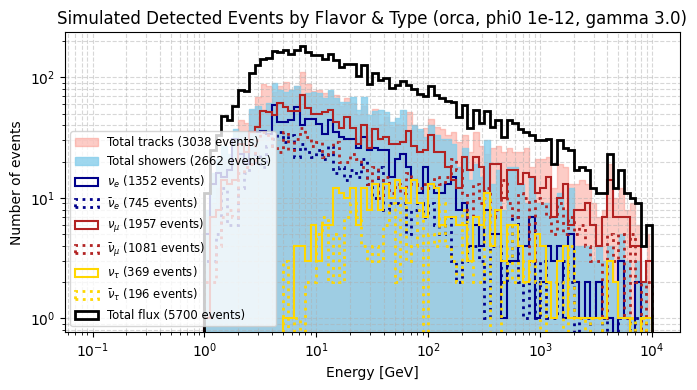

In [79]:
from astropy.coordinates import SkyCoord
from km3astro.frame import get_location
import astropy.units as u
import matplotlib.pyplot as plt


aeff_dict = {}
for flavor in ['nue', 'anue', 'numu', 'anumu', 'nutau', 'anutau']:
    _, aeff_2d, e_bins, cos_theta_bins = load_aeff("aeff_summary_v9_flavors_orca.hdf5", flavor)
    aeff_dict[flavor] = aeff_2d
    

source_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5"
# Load static RA/Dec from your source file
with h5py.File(source_file, 'r') as f:
    ra = f['skycoord/ra'][()]
    dec = f['skycoord/dec'][()]
    source_skycoord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)


from h5py import File
from astropy.table import Table

#input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_30929077events.hdf5"
#input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4982323events.hdf5"
#input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_7923events.hdf5"
#input_file = "/home/wecapstor3/capn/capn107h/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4982323events_mc.hdf5"
# input_file = "/home/wecapstor3/capn/capn107h/combined_eventlists/arca_KM3NeT_00000133_0001_combined_30929077events_data.hdf5"
input_file = "/home/wecapstor3/capn/capn107h/combined_eventlists/orca_KM3NeT_00000148_0001_combined_1008510events_mc.hdf5"

with File(input_file, 'r') as h5_file:
        eventList = Table.read(h5_file)
        time = eventList['time'] #.value.astype(float)

detectorname = 'orca'
detector_location = get_location(detectorname)
observation_times = np.linspace(time.min(), time.max(),1000)

E_min, E_max = 1e0, 1e4

n_energy_bins, n_theta_bins = 100, 100
energy_bins = np.logspace(np.log10(E_min), np.log10(E_max), n_energy_bins + 1)
cos_theta_bins = np.linspace(-1.0, 1.0, n_theta_bins + 1)
dcos = np.diff(cos_theta_bins)


energies, n_total, n_em_showers, event_df, shower_energies, track_energies = simulate_events_all_flavors(
    phi0=1e-12,
    energy_bins=e_bins,
    theta_bin_edges=np.arccos(cos_theta_bins[::-1]),  # Important: convert cos(theta) to theta
    aeff_dict=aeff_dict,
    source_coord=source_skycoord,
    times=observation_times,
    location=detector_location,
    detectorname=detectorname,
    days=90,
    gamma=3.0,
    plot=True,
    plot_config=plot_config
)

print(f"Total events: {n_total}")
print(f"EM shower events (nu_e, anti_nu_e): {n_em_showers}")
print(event_df.head())


In [80]:
import numpy as np
import h5py
from h5py import File
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from km3astro.frame import get_location

def run_simulation_for_detectors(
    detectorname,
    phi0_list,
    gamma_list,
    source_file="/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5",
    plot_config=None,
):
    # Choose Aeff and input file paths based on detectorname
    if detectorname.lower() == "orca":
        aeff_file = "aeff_summary_v9_flavors_orca.hdf5"
        input_file = "/home/wecapstor3/capn/capn107h/combined_eventlists/orca_KM3NeT_00000148_0001_combined_1008510events_mc.hdf5"
    elif detectorname.lower() == "arca":
        aeff_file = "aeff_summary_v9_flavors_arca.hdf5"
        input_file = "/home/wecapstor3/capn/capn107h/combined_eventlists/arca_KM3NeT_00000133_0001_combined_30929077events_data.hdf5"
    else:
        raise ValueError(f"Detector name '{detectorname}' not recognized. Use 'orca' or 'arca'.")

    # Load effective area for each flavor
    aeff_dict = {}
    for flavor in ['nue', 'anue', 'numu', 'anumu', 'nutau', 'anutau']:
        _, aeff_2d, e_bins, cos_theta_bins = load_aeff(aeff_file, flavor)
        aeff_dict[flavor] = aeff_2d

    # Load source sky coordinates from file
    with h5py.File(source_file, 'r') as f:
        ra = f['skycoord/ra'][()]
        dec = f['skycoord/dec'][()]
        source_skycoord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)

    # Load event times from combined event file
    with File(input_file, 'r') as h5_file:
        eventList = Table.read(h5_file)
        time = eventList['time']

    detector_location = get_location(detectorname)
    observation_times = np.linspace(time.min(), time.max(), 1000)

    # Energy and theta bins (from loaded aeff file)
    # Assuming e_bins and cos_theta_bins from load_aeff are compatible with simulate_events_all_flavors
    energy_bins = e_bins
    theta_bin_edges = np.arccos(cos_theta_bins[::-1])  # convert cos(theta) to theta

    # Loop over all phi0 and gamma values
    for phi0 in phi0_list:
        for gamma in gamma_list:
            energies, n_total, n_em_showers, event_df, shower_energies, track_energies = simulate_events_all_flavors(
                phi0=phi0,
                energy_bins=energy_bins,
                theta_bin_edges=theta_bin_edges,
                aeff_dict=aeff_dict,
                source_coord=source_skycoord,
                times=observation_times,
                location=detector_location,
                detectorname=detectorname,
                days=90,
                gamma=gamma,
                plot=False,  # we'll handle plotting ourselves with your updated plot function
                plot_config=plot_config
            )

            print(f"[{detectorname} - phi0={phi0}, gamma={gamma}] Total events: {n_total}")
            print(f"[{detectorname} - phi0={phi0}, gamma={gamma}] EM shower events (nu_e, anti_nu_e): {n_em_showers}")

            # Plot using your updated plotting function that includes counts in labels & filename
            plot_event_energies(
                df_events=event_df,
                energy_bins=energy_bins,
                total_energies=energies,
                detectorname=detectorname,
                phi0=phi0,
                gamma=gamma,
                plot_config=plot_config
            )


em_shower_events:  0
df_events:          energy flavor event_type
0  2650.082992   numu      track
[orca - phi0=1e-12, gamma=1.5] Total events: 1
[orca - phi0=1e-12, gamma=1.5] EM shower events (nu_e, anti_nu_e): 0
em_shower_events:  3
df_events:           energy flavor event_type
0    707.698651    nue     shower
1   3440.914268   anue     shower
2    120.779429   anue     shower
3   1859.298274   numu      track
4   8550.771874   numu      track
5   4956.924578   numu      track
6   5981.114340   numu      track
7   5728.687397  anumu      track
8   1922.028559  anumu      track
9    431.148852  anumu      track
10   298.604211  nutau     shower
11   166.228158  nutau     shower
12  6282.757297  nutau     shower
13  3626.000295  nutau     shower
14  1334.656417  nutau     shower
[orca - phi0=1e-12, gamma=2.0] Total events: 15
[orca - phi0=1e-12, gamma=2.0] EM shower events (nu_e, anti_nu_e): 3
em_shower_events:  34
df_events:            energy  flavor event_type
0    9293.254348     

/tmp/ipykernel_1570783/3059864074.py:45: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(7, 4))


em_shower_events:  87856
df_events:                energy  flavor event_type
0       1.580471e+07     nue     shower
1       1.278340e+05     nue     shower
2       5.805813e+06     nue     shower
3       2.547815e+07     nue     shower
4       8.020673e+05     nue     shower
...              ...     ...        ...
462937  5.366521e+06  anutau     shower
462938  5.731097e+07  anutau     shower
462939  2.040138e+07  anutau     shower
462940  4.853077e+06  anutau     shower
462941  5.669930e+07  anutau     shower

[462942 rows x 3 columns]
[arca - phi0=1e-09, gamma=1.5] Total events: 462942
[arca - phi0=1e-09, gamma=1.5] EM shower events (nu_e, anti_nu_e): 87856
em_shower_events:  46104
df_events:                energy  flavor event_type
0       9.205017e+03     nue     shower
1       1.480199e+06     nue     shower
2       2.235758e+03     nue     shower
3       2.644159e+05     nue     shower
4       2.213430e+06     nue     shower
...              ...     ...        ...
245783  6.5470

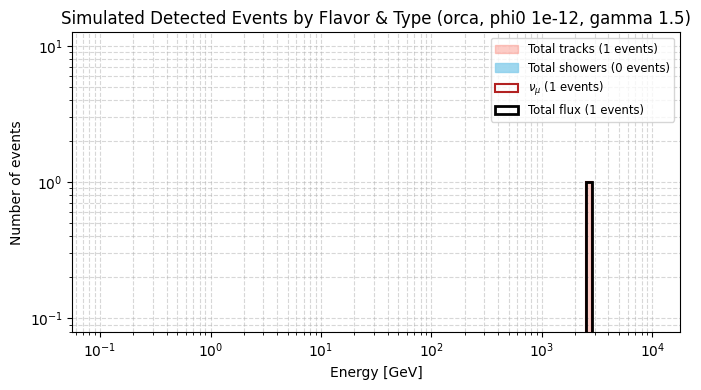

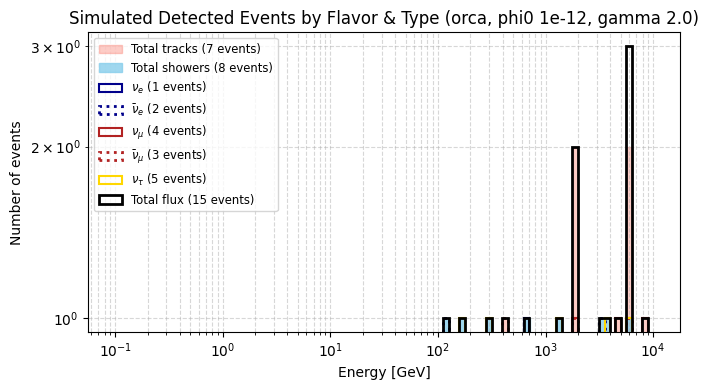

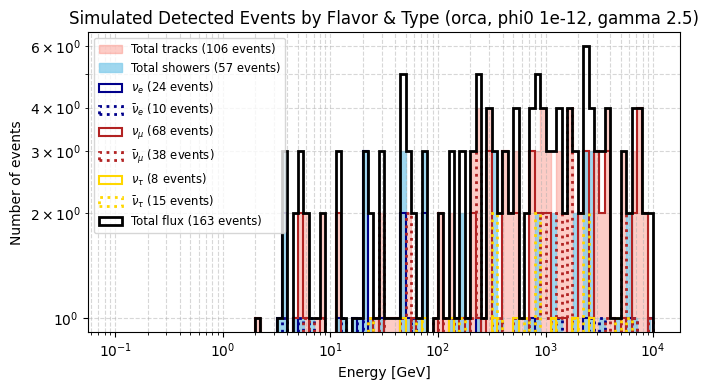

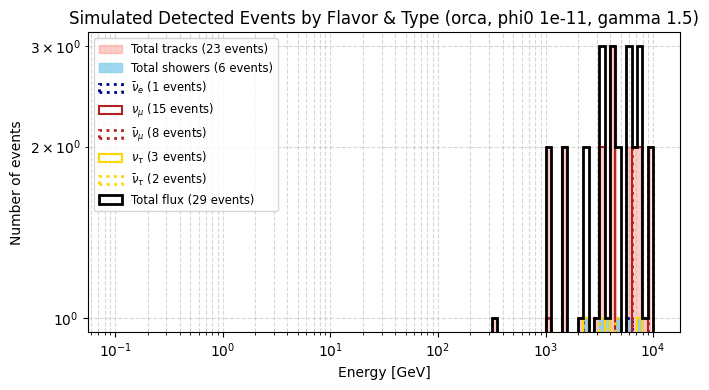

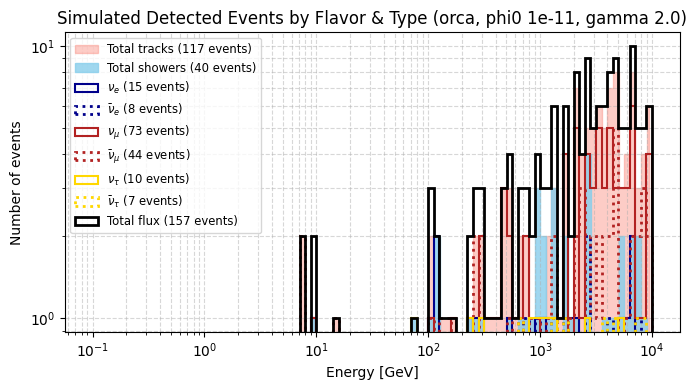

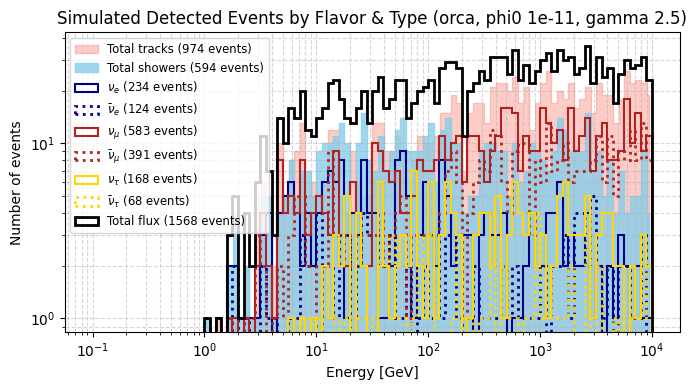

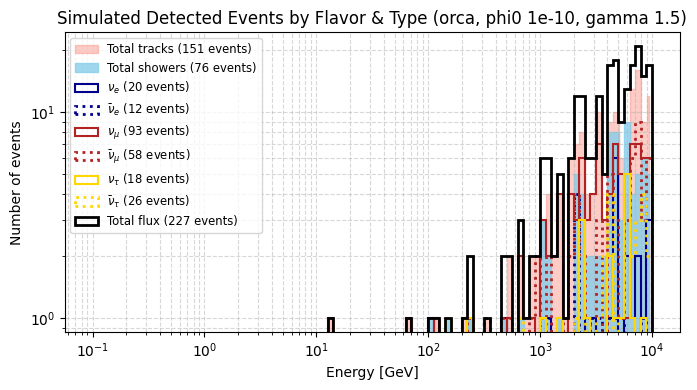

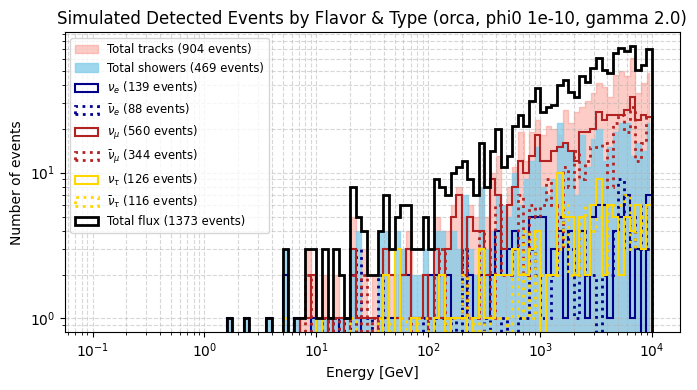

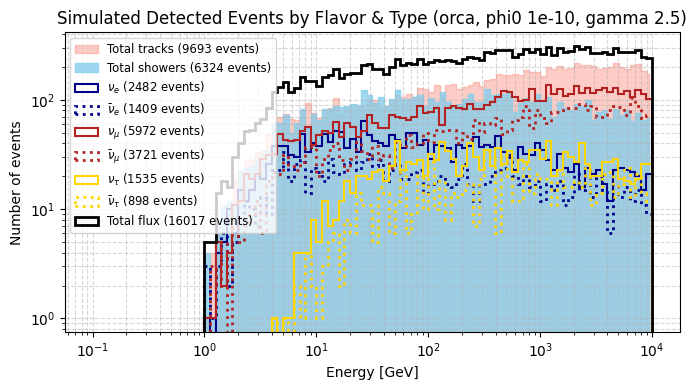

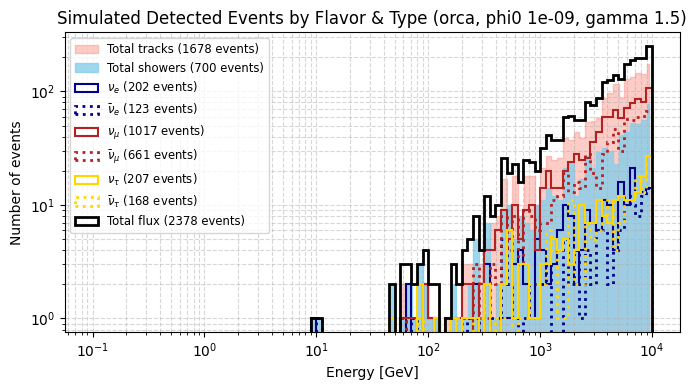

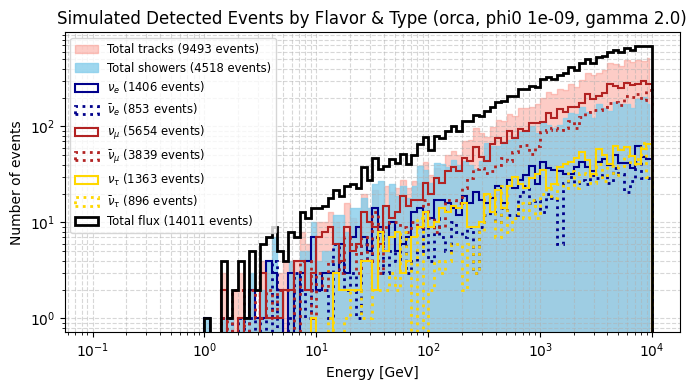

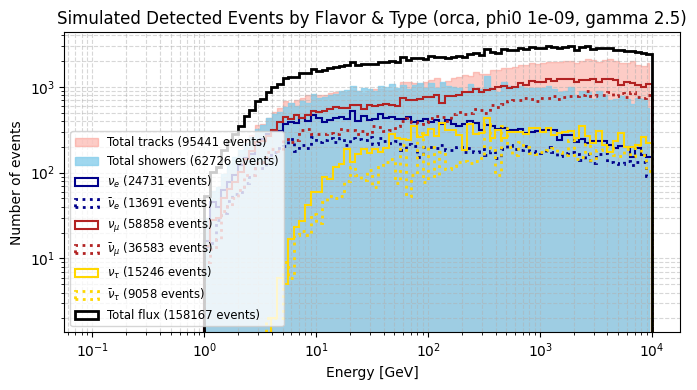

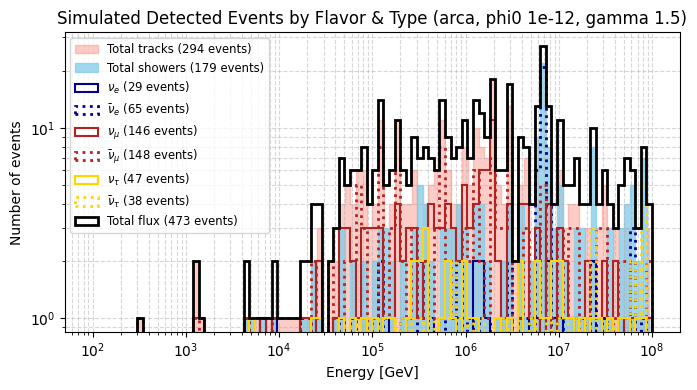

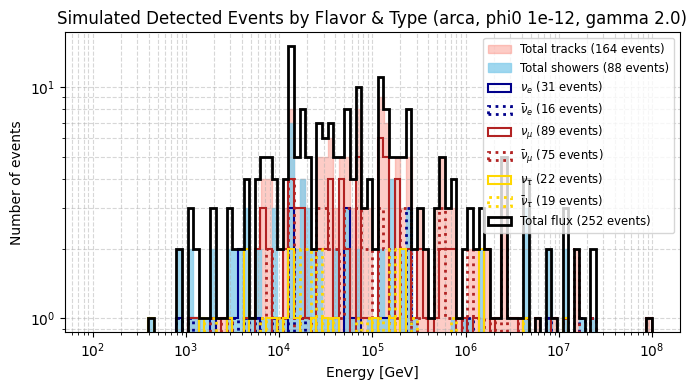

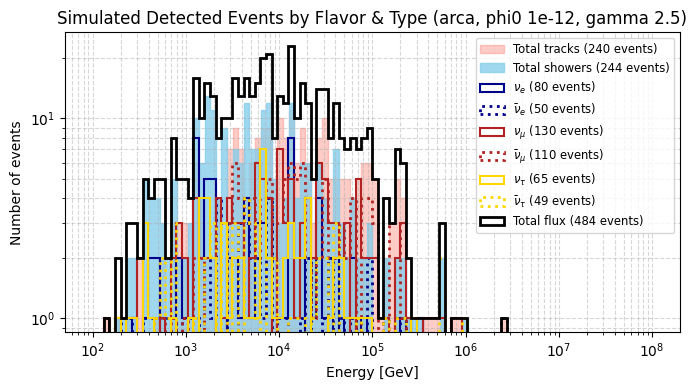

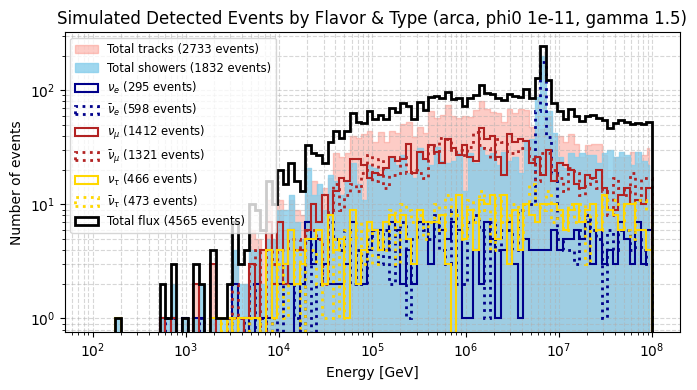

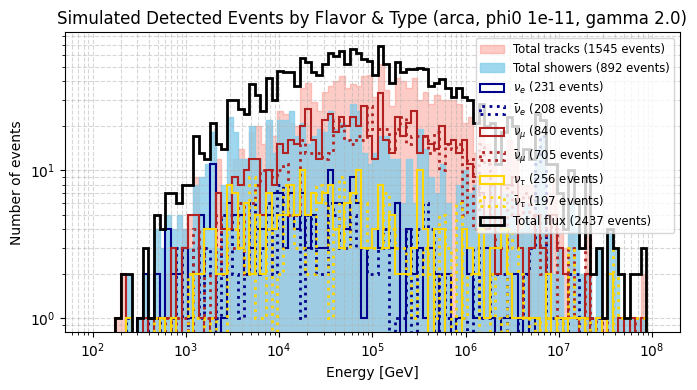

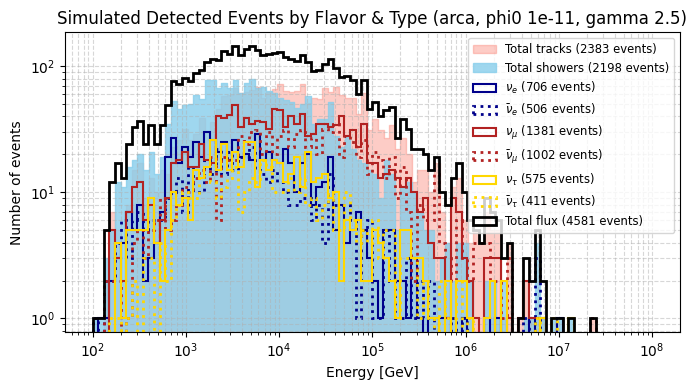

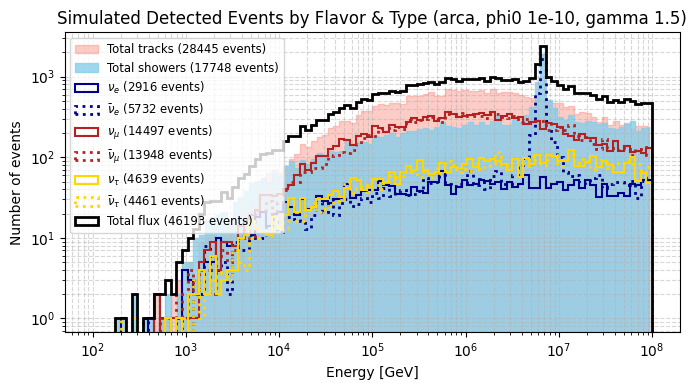

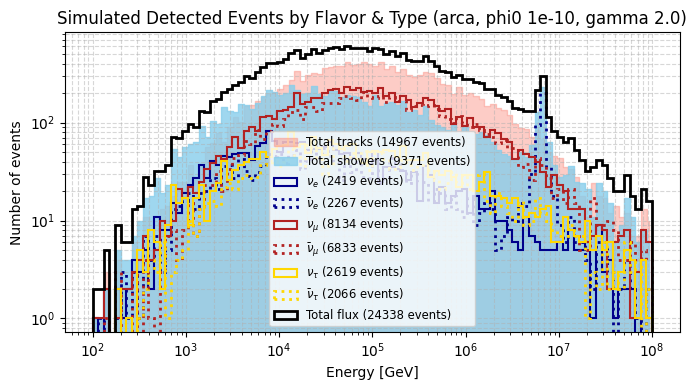

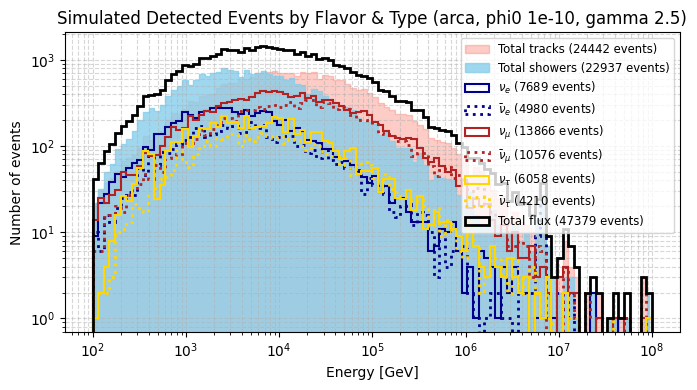

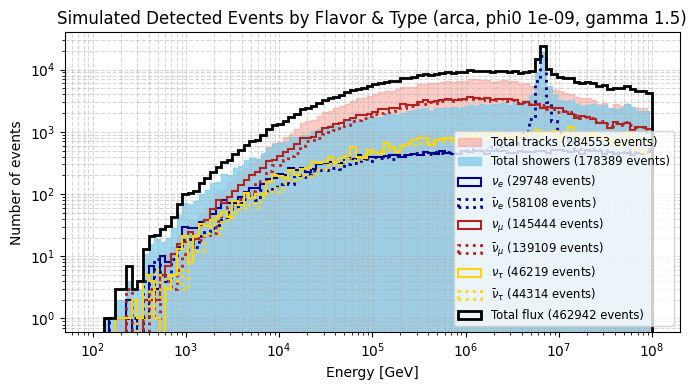

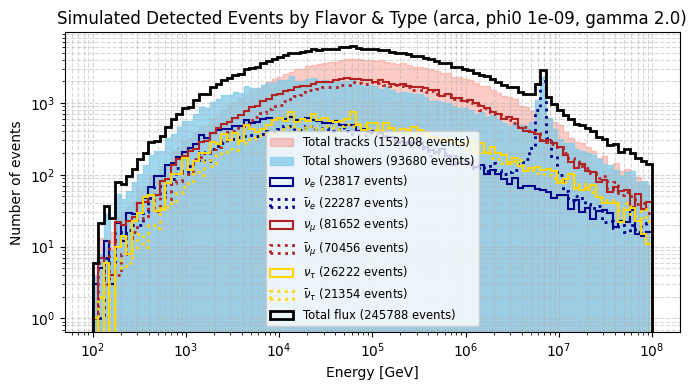

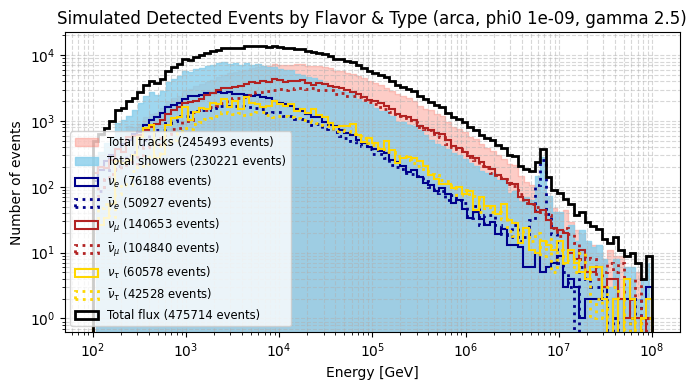

In [82]:
phi0_values = [1e-12, 1e-11, 1e-10, 1e-9]
gamma_values = [1.5, 2.0, 2.5]

run_simulation_for_detectors("orca", phi0_values, gamma_values,plot_config=plot_config)
run_simulation_for_detectors("arca", phi0_values, gamma_values,plot_config=plot_config)


### Sampling of reconstructed energies from expected detected

In [142]:
from h5py import File

def load_histogram(file_path):
    with File(file_path, 'r') as f:
        hist2d = f['hist2d'][()]
        bins_true = f['bins_true'][()]
        bins_reco = f['bins_reco'][()]
    return hist2d, bins_true, bins_reco

histogram_file = "arca_energy_response_histogram.hdf5pdgid14.hdf5"
#histogram_file = "arca_energy_response_histogram.hdf5"
hist2d, bins_true, bins_reco = load_histogram(histogram_file)

In [113]:
import os
import re
from h5py import File

# Define the PDGID to flavor mapping
PDGID_TO_FLAVOR = {
    12: 'nue',
    -12: 'anue',
    14: 'numu',
    -14: 'anumu',
    16: 'nutau',
    -16: 'anutau'
}

def load_histogram(file_path):
    with File(file_path, 'r') as f:
        hist2d = f['hist2d'][()]
        bins_true = f['bins_true'][()]
        bins_reco = f['bins_reco'][()]
    return hist2d, bins_true, bins_reco

def load_histograms_by_pdgid(folder_path):
    histograms = {}
    for filename in os.listdir(folder_path):
        match = re.search(r'pdgid(-?\d+)\.hdf5$', filename)
        if match:
            pdgid = int(match.group(1))
            flavor = PDGID_TO_FLAVOR.get(pdgid)
            if flavor:
                file_path = os.path.join(folder_path, filename)
                histograms[flavor] = load_histogram(file_path)
    return histograms


In [114]:
folder_path = '.'
histograms = load_histograms_by_pdgid(folder_path)

# Example: access the histogram for muon neutrino
hist2d_numu, bins_true_numu, bins_reco_numu = histograms['numu']


In [120]:
# Shower response (e.g., nue, anue, nutau, anutau)
shower_hist2d, shower_bins_true, shower_bins_reco = load_histogram(
    "/home/hpc/capn/capn107h/software/psr/src/notebooks/orca_energy_response_histogram_shower_pdgid12_-12_16_-16.hdf5"
)

# Track response (e.g., numu, anumu)
track_hist2d, track_bins_true, track_bins_reco = load_histogram(
    "/home/hpc/capn/capn107h/software/psr/src/notebooks/orca_energy_response_histogram_track_pdgid14_-14.hdf5"
)

# Assuming these are NumPy arrays from simulate_events_all_flavors
# shower_energies, track_energies




Successfully sampled: 13322 / 14194


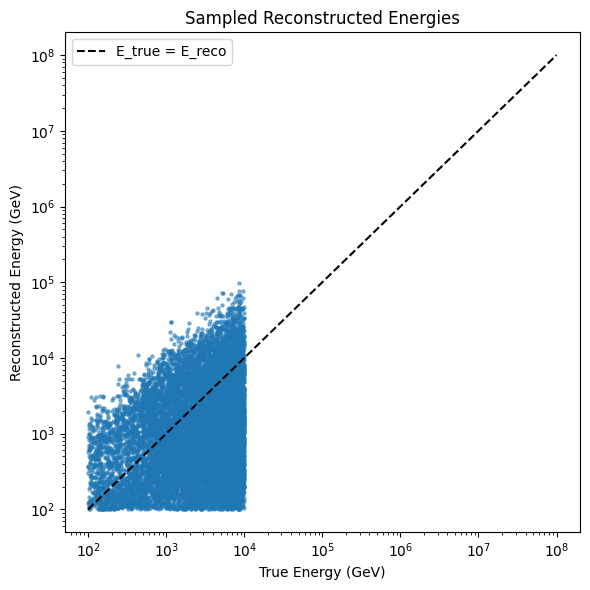

ValueError: Data has no positive values, and therefore cannot be log-scaled.

Error in callback <function _draw_all_if_interactive at 0x7f03ff765550> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 800x500 with 1 Axes>

In [116]:
def sample_reco_energy_array(true_energies, hist2d, bins_true, bins_reco):
    """
    Samples reconstructed energies for an array of true energies based on a 2D histogram.

    Parameters:
    - true_energies: array-like, true neutrino energies
    - hist2d: 2D array of shape (n_true_bins, n_reco_bins), probability distribution
    - bins_true: edges of true energy bins
    - bins_reco: edges of reco energy bins

    Returns:
    - reco_samples: sampled reconstructed energies
    - failed_mask: boolean mask for entries that failed to sample (outside bin range or empty PDF)
    """
    true_energies = np.asarray(true_energies)
    reco_samples = np.full_like(true_energies, np.nan, dtype=float)

    for i, E_true in enumerate(true_energies):
        true_bin_idx = np.digitize(E_true, bins_true) - 1

        # Check if within valid range
        if 0 <= true_bin_idx < hist2d.shape[0]:
            slice_hist = hist2d[true_bin_idx, :]
            if np.sum(slice_hist) > 0:
                pdf = slice_hist / np.sum(slice_hist)
                reco_bin_idx = np.random.choice(len(pdf), p=pdf)

                # Sample uniformly in the selected reco bin
                reco_lo = bins_reco[reco_bin_idx]
                reco_hi = bins_reco[reco_bin_idx + 1]
                reco_samples[i] = np.random.uniform(reco_lo, reco_hi)

    failed_mask = np.isnan(reco_samples)
    return reco_samples, failed_mask

E_reco_samples, failed = sample_reco_energy_array(energies, track_hist2d, track_bins_true, track_bins_reco)

# Print how many succeeded
print(f"Successfully sampled: {(~failed).sum()} / {len(energies)}")


# Example plot: true vs reco energies
plt.figure(figsize=(6, 6))
plt.scatter(energies[~failed], E_reco_samples[~failed], s=5, alpha=0.5)
plt.plot([1e2, 1e8], [1e2, 1e8], 'k--', label='E_true = E_reco')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("True Energy (GeV)")
plt.ylabel("Reconstructed Energy (GeV)")
plt.title("Sampled Reconstructed Energies")
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
E_min = E_reco_samples.min()
E_max = E_reco_samples.max()
gamma = 2.0

bins = np.logspace(np.log10(E_min), np.log10(E_max), 50)
plt.hist(energies, bins=bins, histtype='step', color='darkblue', label=f'E_true')#, density=True)
plt.hist(E_reco_samples, bins=bins, histtype='step', color='darkorange', label=f'E_reco')#, density=True)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy')
plt.ylabel('Number of Events')
plt.title('Sampled Power-Law Energy Spectrum')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [121]:

reco_shower_energies, failed_shower = sample_reco_energy_array(
    shower_energies, shower_hist2d, shower_bins_true, shower_bins_reco
)

reco_track_energies, failed_track = sample_reco_energy_array(
    track_energies, track_hist2d, track_bins_true, track_bins_reco
)

reco_combined_energies = np.concatenate((reco_track_energies, reco_shower_energies))
combined_energies = np.concatenate((track_energies, shower_energies))

print(reco_combined_energies)
print(reco_shower_energies)
print(reco_track_energies)

[  312.9924854   3907.39318701   889.30881089 ...   438.26281701
  1541.40318101 12035.0389391 ]
[           nan 28131.79359698  1328.57454818 ...   438.26281701
  1541.40318101 12035.0389391 ]
[ 312.9924854  3907.39318701  889.30881089 ... 4792.80614431  395.10894244
 1847.79181521]


In [117]:
plt.figure(figsize=(6, 6))
plt.scatter(track_energies[~failed_track],reco_track_energies[~failed_track], s=5, alpha=0.5)
plt.plot([1e2, 1e8], [1e2, 1e8], 'k--', label='E_true = E_reco')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("True Energy (GeV)")
plt.ylabel("Reconstructed Energy (GeV)")
plt.title("Sampled Reconstructed Energies")
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
E_min = reco_track_energies.min()
E_max = reco_track_energies.max()
gamma = 2.0

bins = np.logspace(np.log10(E_min), np.log10(E_max), 50)
plt.hist(shower_energies, bins=bins, histtype='step', color='darkblue',lw=2, alpha=0.7, label=f'E_true_shower')#, density=True)
plt.hist(reco_shower_energies, bins=bins, histtype='step',ls='dotted',lw=2, color='darkblue', label=f'E_reco_shower')#, density=True)
plt.hist(combined_energies, bins=bins, histtype='step', color='black',lw=2,alpha=0.7, label=f'E_true_combined')
plt.hist(reco_combined_energies, bins=bins, histtype='step',ls='dotted', lw=2, color='black', label=f'E_reco_combined')
plt.hist(track_energies, bins=bins, histtype='step',  color='firebrick',lw=2,alpha=0.7, label=f'E_true_track')#, density=True)
plt.hist(reco_track_energies, bins=bins, histtype='step',ls='dotted',lw=2, color='firebrick', label=f'E_reco_track')#, density=True)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy')
plt.ylabel('Number of Events')
plt.title('Simulated Reconstruction Response')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("Tempplot3.png")

IndexError: boolean index did not match indexed array along dimension 0; dimension is 9714 but corresponding boolean dimension is 955

<Figure size 600x600 with 0 Axes>

In [118]:
import numpy as np
import matplotlib.pyplot as plt

# --- Helper function ---
def safe_array(a):
    """Return only finite and positive values of an array"""
    return a[np.isfinite(a) & (a > 0)]

def mask_positive_finite(*arrays):
    """Return a mask that is True where all arrays are finite and > 0"""
    mask = np.ones_like(arrays[0], dtype=bool)
    for arr in arrays:
        mask &= np.isfinite(arr) & (arr > 0)
    return mask

# --- Plot 1: Scatter plot ---
plt.figure(figsize=(6, 6))

x = track_energies[~failed_track]
y = reco_track_energies[~failed_track]
valid = mask_positive_finite(x, y)

plt.scatter(x[valid], y[valid], s=5, alpha=0.5)
plt.plot([1e2, 1e8], [1e2, 1e8], 'k--', label='E_true = E_reco')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("True Energy (GeV)")
plt.ylabel("Reconstructed Energy (GeV)")
plt.title("Sampled Reconstructed Energies")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Histograms ---

# Collect all relevant energies into one array to get a safe min/max for bins
all_energies = np.concatenate([
    safe_array(shower_energies),
    safe_array(reco_shower_energies),
    safe_array(combined_energies),
    safe_array(reco_combined_energies),
    safe_array(track_energies),
    safe_array(reco_track_energies)
])

E_min = all_energies.min()
E_max = all_energies.max()
bins = np.logspace(np.log10(E_min), np.log10(E_max), 50)

plt.figure(figsize=(8, 5))

plt.hist(safe_array(shower_energies), bins=bins, histtype='step', color='darkblue', lw=2, alpha=0.7, label='E_true_shower')
plt.hist(safe_array(reco_shower_energies), bins=bins, histtype='step', ls='dotted', lw=2, color='darkblue', label='E_reco_shower')
plt.hist(safe_array(combined_energies), bins=bins, histtype='step', color='black', lw=2, alpha=0.7, label='E_true_combined')
plt.hist(safe_array(reco_combined_energies), bins=bins, histtype='step', ls='dotted', lw=2, color='black', label='E_reco_combined')
plt.hist(safe_array(track_energies), bins=bins, histtype='step', color='firebrick', lw=2, alpha=0.7, label='E_true_track')
plt.hist(safe_array(reco_track_energies), bins=bins, histtype='step', ls='dotted', lw=2, color='firebrick', label='E_reco_track')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy')
plt.ylabel('Number of Events')
plt.title('Simulated Reconstruction Response')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("Tempplot3.png")


IndexError: boolean index did not match indexed array along dimension 0; dimension is 9714 but corresponding boolean dimension is 955

<Figure size 600x600 with 0 Axes>

#### Outdated: Calculate event times

In [119]:
from docopt import docopt
import h5py as h5py
import numpy as np
from plens.PulseModel import MVMD, sinusoid
from stingray import EventList, Lightcurve
import matplotlib.pyplot as plt
import km3io.definitions as kd


def inject_signal_times(time, energy, reco_energies_to_inject, bin_time, pulseshape, frequency,
                        baseline, a, phi, method='classic', kappa=None, num_periods=20, plot=False):
    """
    Injects signal times into an event list using a chosen method ('classic' or 'base').

    Parameters:
        time : np.array
            Original event times.
        energy : np.array
            Original event energies.
        reco_energies_to_inject : np.array
            Pre-sampled reconstructed energies to inject.
        bin_time : float
            Time bin width.
        pulseshape : str
            Pulse shape to use ('sine' or 'mvm').
        frequency : float
            Frequency of the pulse train.
        baseline : float
            Baseline offset.
        a : float
            Amplitude of the signal.
        phi : float
            Phase shift.
        method : str
            Injection method ('classic' or 'base').
        kappa : float, optional
            Shape parameter for MVM.
        num_periods : int
            Only used if method='base'. Number of periods for base interval.
        plot : bool
            Whether to return internal lightcurves for diagnostics.

    Returns:
        tuple: (combined_times, combined_energies) or diagnostic output if plot=True.
    """
    n_events_inject = len(reco_energies_to_inject)
    total_events = len(time)
    num_original_events_to_keep = total_events - n_events_inject

    if num_original_events_to_keep < 0:
        raise ValueError("Number of injected events exceeds original events.")

    if method == 'classic':
        high_res_bin_time = 1e-1
        high_res_time = np.arange(time.min(), time.max(), high_res_bin_time)

        if pulseshape == 'mvm':
            counts = MVMD(high_res_time, frequency, phi, kappa, a, baseline=baseline)
        elif pulseshape == 'sine':
            counts = sinusoid(high_res_time, frequency, baseline, a, phi)
        else:
            raise ValueError("Invalid pulseshape")

        lc_original = Lightcurve(high_res_time, counts, dt=high_res_bin_time / 10, skip_checks=True)
        ev = EventList()
        ev.simulate_times(lc_original)
        new_event_times = ev.time

    elif method == 'base':
        start_time = time.min()
        base_interval_length = num_periods / frequency
        high_res_time = np.arange(start_time, start_time + base_interval_length, bin_time)

        if pulseshape == 'mvm':
            counts = MVMD(high_res_time, frequency, phi, kappa, a, baseline=baseline)
        elif pulseshape == 'sine':
            counts = sinusoid(high_res_time, frequency, baseline, a, phi)
        else:
            raise ValueError("Invalid pulseshape")
        

        lc_base = Lightcurve(high_res_time, counts, dt=bin_time, skip_checks=True)
        ev = EventList()
        ev.simulate_times(lc_base)
        base_event_times = ev.time

        total_time_span = time.max() - time.min()
        num_intervals = int(np.ceil(total_time_span / base_interval_length))
        chosen_base_times = np.random.choice(base_event_times, n_events_inject, replace=True)
        random_shifts = np.random.randint(0, num_intervals, size=n_events_inject) * base_interval_length
        new_event_times = chosen_base_times + random_shifts

    else:
        raise ValueError("Invalid method: choose 'classic' or 'base'")

    # Resample if needed
    if len(new_event_times) >= n_events_inject:
        indices_to_keep_new = np.random.choice(len(new_event_times), n_events_inject, replace=False)
    else:
        indices_to_keep_new = np.random.choice(len(new_event_times), n_events_inject, replace=True)
    new_event_times = new_event_times[indices_to_keep_new]

    # Select original events to keep
    indices_to_keep_original = np.random.choice(len(time), num_original_events_to_keep, replace=False)
    remaining_original_times = time[indices_to_keep_original]
    remaining_original_energies = energy[indices_to_keep_original]

    reco_dirs = sample_reco_directions_from_source_skycoord(
        source_coord=skycoord,
        reco_energies=reco_energies_to_inject,
        resolution_func=lambda e: 0.5,  # 5 deg for now
        detector_location=detector_location,
        observation_time= new_event_times
    )

    # Combine and sort
    combined_times = np.concatenate((remaining_original_times, new_event_times))
    combined_energies = np.concatenate((remaining_original_energies, reco_energies_to_inject))
    sort_indices = np.argsort(combined_times)
    combined_times = combined_times[sort_indices]
    combined_energies = combined_energies[sort_indices]

    return combined_times, combined_energies


In [45]:
from h5py import File
from astropy.table import Table

input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_30929077events.hdf5"
input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4982323events.hdf5"
#input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_7923events.hdf5"
with File(input_file, 'r') as h5_file:
        eventList = Table.read(h5_file)
    
        event_times = eventList['time'].value.astype(float)
        energy = eventList['energy'].value.astype(float)


combined_times, combined_energies = inject_signal_times(
    time=event_times,
    energy=energy,
    reco_energies_to_inject=E_reco_samples,
    bin_time=1e-5,
    pulseshape='mvm',
    frequency=11,
    baseline=0.0,
    a=1.0,
    phi=0.0,
    method='base',
    kappa=5.0
)


### Loading and fitting angular resolutions

In [ ]:
import os

from astropy.table import Table
import numpy as np


from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Functions to fit to the angular resolution distribution
def logistic_function(E, a, b, c, d,e,f):
    return a / (1.0 + np.exp(-b * (np.log10(E) - c))) + d + e * np.maximum(0, np.log10(E) - f)

def polynomial(E, a, b, c, d, e, f, g, h):
    return a * np.log10(E)**4 + b * np.log10(E)**3 + c * np.log10(E)**2 + d * np.log10(E) + e + f*np.log10(E)**5 +g * np.log10(E)**6 +h*np.log10(E)**7





# Function to read HDF5 file and fit the data to a model
def fit_angular_resolution(file_path, output_dir, energy_low, energy_high, fit_type="logistic",plot=False):
    # Open the HDF5 file
    table = Table.read(file_path, format='hdf5')

    # Access the columns by their names
    energy_bin_centers = table['energy_bin_center']
    angular_resolution = table['median_angular_separation']
    sigma1_width = table['sigma1_width']  # Assuming this is the uncertainty

    valid_indices = np.isfinite(angular_resolution) & np.isfinite(sigma1_width) & np.isfinite(energy_bin_centers)

    if not np.all(valid_indices):
        print("Warning: Some values were NaN or Inf and have been removed from the fit.")
        energy_bin_centers = energy_bin_centers[valid_indices]
        angular_resolution = angular_resolution[valid_indices]
        sigma1_width = sigma1_width[valid_indices]



    if fit_type == "logistic":
        # Initial guesses for the logistic function parameters
        popt, _ = curve_fit(logistic_function, energy_bin_centers, angular_resolution, 
                            p0=[2, -1, 4, 0.1,1.0, 8], sigma=sigma1_width, absolute_sigma=True)
        fit_func = lambda E: logistic_function(E, *popt)
        plot_name = os.path.join(output_dir,f"fitted_angular_resolution_tracklike.png")
    elif fit_type == "polymial":
        # Initial guesses for the sinusoidal function parameters
        popt, _ = curve_fit(polynomial, energy_bin_centers, angular_resolution, p0=[0.0,0.0,0.05,-0.3,1.0,0.0,0.0,0.0] ,sigma=sigma1_width, absolute_sigma=True)
        fit_func = lambda E: polynomial(E, *popt)
        plot_name = os.path.join(output_dir,f"fitted_angular_resolution_showerlike.png")
    else:
        raise ValueError("Unknown fit type. Choose 'logistic' or 'polymial'.")
    
    if plot == True:
        # Plot the data and the fit
        plt.figure(figsize=(10, 6))
        plt.plot(energy_bin_centers, angular_resolution, color='black', marker='o', linestyle='none', label='Data')
        energy_fit = np.logspace(energy_low, energy_high, 1000)  # Energy values for plotting the fit
        plt.plot(energy_fit, fit_func(energy_fit), color='firebrick', linestyle='-', linewidth=2, label='Fit')
        plt.xscale('log')
        # Add a shaded 1σ band for uncertainties (optional, depends on your data)
        sigma1_band_lower = angular_resolution - sigma1_width  # Example: replace sigma1_values with your actual 1σ uncertainties
        sigma1_band_upper = angular_resolution + sigma1_width
        plt.fill_between(energy_bin_centers, sigma1_band_lower, sigma1_band_upper, color='blue', alpha=0.3, label='1σ Band')

        # Add a shaded 2σ band for uncertainties (optional)
        sigma2_band_lower = angular_resolution - 2*sigma1_width   # Example: replace sigma2_values with your actual 2σ uncertainties
        sigma2_band_upper = angular_resolution + 2*sigma1_width
        plt.fill_between(energy_bin_centers, sigma2_band_lower, sigma2_band_upper, color='blue', alpha=0.1, label='2σ Band')


        plt.xscale('log')
        # Customize labels and title
        plt.xlabel('Energy [GeV]', fontsize=12)
        plt.ylabel('Angular Resolution [°]', fontsize=12)
        plt.title(f'Angular Resolution vs Energy ({fit_type} Fit Type)', fontsize=14)
        # Add gridlines for better readability
        plt.grid(True, which="both", linestyle="--", linewidth=0.7)
        plt.legend()
        plt.savefig(plot_name)

    return fit_func
         
# ar_shower_file_arca : "${WORKFLOW_DIR}/inputs/angular_res_files/AngularResolutionOverEnergy_aashower_mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013.hdf5",
# ar_track_file_arca : "${WORKFLOW_DIR}/inputs/angular_res_files/AngularResolutionOverEnergy_jmuon_mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5",



file_path_sh = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/angular_res_files/AngularResolutionOverEnergy_aashower_mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013.hdf5"
file_path_tr = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/angular_res_files/AngularResolutionOverEnergy_jmuon_mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5"
fit_func_tr = fit_angular_resolution(file_path_tr,".",2,8,fit_type="logistic")
fit_func_sh = fit_angular_resolution(file_path_sh,".",2,8,fit_type="polymial")

/home/hpc/capn/capn107h/software/km3astrovenv3.9.12/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:968: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
/tmp/ipykernel_406536/2977808349.py:43: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(logistic_function, energy_bin_centers, angular_resolution,


In [122]:
file_path_sh = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/angular_res_files/AngularResolutionOverEnergy_jshower_gsg_elec-CC_1.0-100.0GeV_orca.hdf5"
file_path_tr = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/angular_res_files/AngularResolutionOverEnergy_jmuon_gsg_muon-CC_1.0-100.0GeV_orca.hdf5"
fit_func_tr = fit_angular_resolution(file_path_tr,".",0,2,fit_type="polymial")
fit_func_sh = fit_angular_resolution(file_path_sh,".",0,2,fit_type="polymial")

### New approach to calculate event times to the sampled energies with direction sampling from below providing new azimuth and zenith

In [123]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord, AltAz, EarthLocation
from astropy.time import Time

import h5py as h5py
import numpy as np
from plens.PulseModel import MVMD, sinusoid
from stingray import EventList, Lightcurve
import matplotlib.pyplot as plt
import km3io.definitions as kd

def sample_reco_directions_from_source_skycoord(
    source_coord,
    reco_energies,
    resolution_func,
    detector_location,
    observation_time
):
    """
    Simulate reconstructed directions (zenith, azimuth) around a source SkyCoord.

    Parameters:
    - source_coord: SkyCoord
        The true source celestial coordinate.
    - reco_energies: np.ndarray
        Reconstructed energies for the injected events.
    - resolution_func: callable
        Function that maps energy to angular resolution in degrees.
    - detector_location: EarthLocation
        Location of the detector.
    - observation_time: Time or float
        Observation time (astropy Time or UNIX timestamp).

    Returns:
    - dict with 'zenith', 'azimuth', 'zenith_true', 'azimuth_true', 'separation'
    """

    # Ensure time is Time object
    if isinstance(observation_time, (float, int)):
        observation_time = Time(observation_time, format='unix')

    n_events = len(reco_energies)
    ang_res_deg = resolution_func(reco_energies)  # e.g., 1-40 deg

    # Create duplicated SkyCoord array for source
    source_coords = SkyCoord(
        ra=np.full(n_events, source_coord.ra.degree) * u.deg,
        dec=np.full(n_events, source_coord.dec.degree) * u.deg,
        frame='icrs'
    )

    # Convert angular resolution (in deg) to radians and sample points
    angular_offsets = np.random.normal(loc=0, scale=ang_res_deg, size=n_events) * u.deg
    position_angles = np.random.uniform(0, 360, size=n_events) * u.deg

    # Offset the source in RA/Dec by these angles
    smeared_coords = source_coords.directional_offset_by(position_angles, angular_offsets)

    # Transform to AltAz (local detector frame)
    altaz_frame = AltAz(obstime=observation_time, location=detector_location)
    smeared_altaz = smeared_coords.transform_to(altaz_frame)
    true_altaz = source_coord.transform_to(altaz_frame)

    azimuths = smeared_altaz.az.to(u.deg).value
    zeniths = (90 * u.deg - smeared_altaz.alt).to(u.deg).value

    # Also return true direction
    az_true = true_altaz.az.to(u.deg).value
    zen_true = (90 * u.deg - true_altaz.alt).to(u.deg).value

    return {
        'zenith': zeniths,
        'azimuth': azimuths,
        'zenith_true': np.full(n_events, zen_true),
        'azimuth_true': np.full(n_events, az_true),
        'skycoord': smeared_coords,
        'separation': smeared_coords.separation(source_coord).to(u.deg).value
    }


In [124]:
import numpy as np

from astropy.coordinates import ICRS, Galactic, FK4, FK5  # Low-level frames
import astropy.units as u
from astropy.units import rad, deg, hourangle  # noqa

from astropy.coordinates import (
    EarthLocation,
    SkyCoord,
    AltAz,
    Longitude,
    Latitude,
)

from km3astro.constants import (
    arca_longitude,
    arca_latitude,
    arca_height,
    orca_longitude,
    orca_latitude,
    orca_height,
    antares_longitude,
    antares_latitude,
    antares_height,
)

LOCATIONS = {
    "arca": EarthLocation.from_geodetic(
        lon=Longitude(arca_longitude * deg),
        lat=Latitude(arca_latitude * deg),
        height=arca_height,
    ),
    "orca": EarthLocation.from_geodetic(
        lon=Longitude(orca_longitude * deg),
        lat=Latitude(orca_latitude * deg),
        height=orca_height,
    ),
    "antares": EarthLocation.from_geodetic(
        lon=Longitude(antares_longitude * deg),
        lat=Latitude(antares_latitude * deg),
        height=antares_height,
    ),
}


def get_location(location):
    try:
        loc = LOCATIONS[location]
    except KeyError:
        raise KeyError("Invalid location, valid are 'orca', 'arca', 'antares'")
    return loc


In [125]:
import numpy as np
from astropy.time import Time




def inject_signal_times(time, energy, zenith, azimuth, reco_energies_to_inject, reco_types_to_inject, bin_time, pulseshape, frequency,
                        baseline, a, phi, method='classic', kappa=None, num_periods=20, plot=False,
                        skycoord=None, detector_location=None, print_summary=True, preview_n=5, track_resolution_func = None, shower_resolution_func = None):
    """
    Injects signal times into an event list and returns the combined times, energies, and directions.
    Optionally prints a summary of event counts and previews a few example events.

    Parameters:
        ...
        print_summary : bool
            Whether to print a summary of the injection process.
        preview_n : int
            Number of randomly selected events to print as a preview.
    """
    n_events_inject = len(reco_energies_to_inject)
    total_events = len(time)
    num_original_events_to_keep = total_events - n_events_inject

    if num_original_events_to_keep < 0:
        raise ValueError("Number of injected events exceeds original events.")

    # --- Injection process ---
    if method == 'classic':
        high_res_bin_time = 1e-1
        high_res_time = np.arange(time.min(), time.max(), high_res_bin_time)

        if pulseshape == 'mvm':
            counts = MVMD(high_res_time, frequency, phi, kappa, a, baseline=baseline)
        elif pulseshape == 'sine':
            counts = sinusoid(high_res_time, frequency, baseline, a, phi)
        else:
            raise ValueError("Invalid pulseshape")

        lc_original = Lightcurve(high_res_time, counts, dt=high_res_bin_time / 10, skip_checks=True)
        ev = EventList()
        ev.simulate_times(lc_original)
        new_event_times = ev.time

    elif method == 'base':
        start_time = time.min()
        base_interval_length = num_periods / frequency
        high_res_time = np.arange(start_time, start_time + base_interval_length, bin_time)

        if pulseshape == 'mvm':
            counts = MVMD(high_res_time, frequency, phi, kappa, a, baseline=baseline)
        elif pulseshape == 'sine':
            counts = sinusoid(high_res_time, frequency, baseline, a, phi)
        else:
            raise ValueError("Invalid pulseshape")

        lc_base = Lightcurve(high_res_time, counts, dt=bin_time, skip_checks=True)
        ev = EventList()
        ev.simulate_times(lc_base)
        base_event_times = ev.time

        total_time_span = time.max() - time.min()
        num_intervals = int(np.ceil(total_time_span / base_interval_length))
        chosen_base_times = np.random.choice(base_event_times, n_events_inject, replace=True)
        random_shifts = np.random.randint(0, num_intervals, size=n_events_inject) * base_interval_length
        new_event_times = chosen_base_times + random_shifts

    else:
        raise ValueError("Invalid method: choose 'classic' or 'base'")

    # --- Resample injected events if needed ---
    if len(new_event_times) >= n_events_inject:
        indices_to_keep_new = np.random.choice(len(new_event_times), n_events_inject, replace=False)
    else:
        indices_to_keep_new = np.random.choice(len(new_event_times), n_events_inject, replace=True)
    new_event_times = new_event_times[indices_to_keep_new]

    # --- Select original events to keep ---
    indices_to_keep_original = np.random.choice(len(time), num_original_events_to_keep, replace=False)
    remaining_original_times = time[indices_to_keep_original]
    remaining_original_energies = energy[indices_to_keep_original]
    remaining_original_zeniths = zenith[indices_to_keep_original]
    remaining_original_azimuths = azimuth[indices_to_keep_original]

    assert len(reco_types_to_inject) == len(reco_energies_to_inject), "Mismatch between types and energies"

    def resolution_func_per_event(energies):
        # Input: array of energies
        # Output: array of angular resolutions
        resolutions = np.zeros_like(energies)
        mask_track = np.array(reco_types_to_inject) == 'track'
        mask_shower = np.array(reco_types_to_inject) == 'shower'
        
        resolutions[mask_track] = track_resolution_func(np.array(energies)[mask_track])
        resolutions[mask_shower] = shower_resolution_func(np.array(energies)[mask_shower])
        
        return resolutions

    # --- Sample directions for injected events ---
    reco_dirs = sample_reco_directions_from_source_skycoord(
        source_coord=skycoord,
        reco_energies=reco_energies_to_inject,
        #resolution_func=lambda e: 0.5,  # 5 deg resolution for now
        resolution_func = resolution_func_per_event,
        detector_location=detector_location,
        observation_time=Time(new_event_times, format='unix')
    )

    def plot_reco_directions(result, title="Reconstructed Directions"):
        zen = result['zenith']
        az = result['azimuth']
        zen_true = result['zenith_true'][0]
        az_true = result['azimuth_true'][0]

        fig, ax = plt.subplots(figsize=(6, 6))
        sc = ax.scatter(az, zen, s=2, alpha=0.5, label='Reconstructed Events', color='blue')
        ax.plot(az_true, zen_true, marker='*', color='red', markersize=5, label='Source')

        ax.set_xlim(0, 360)
        ax.set_ylim(0, 180)
        ax.set_xlabel("Azimuth (°)")
        ax.set_ylabel("Zenith (°)")
        ax.set_title(title)
        ax.legend()
        ax.grid(True)
        plt.tight_layout()

        plt.show()
    if plot == True:
        plot_reco_directions(reco_dirs)

    
    new_event_zeniths = reco_dirs['zenith']
    new_event_azimuths = reco_dirs['azimuth']

    # --- Combine and sort ---
    combined_times = np.concatenate((remaining_original_times, new_event_times))
    combined_energies = np.concatenate((remaining_original_energies, reco_energies_to_inject))
    combined_zeniths = np.concatenate((remaining_original_zeniths, new_event_zeniths))
    combined_azimuths = np.concatenate((remaining_original_azimuths, new_event_azimuths))

    sort_indices = np.argsort(combined_times)
    combined_times = combined_times[sort_indices]
    combined_energies = combined_energies[sort_indices]
    combined_zeniths = combined_zeniths[sort_indices]
    combined_azimuths = combined_azimuths[sort_indices]

    # --- Summary Output ---
    if print_summary:
        print("\n--- Signal Injection Summary ---")
        print(f"Total original events:      {total_events}")
        print(f"Simulated (injected) events: {n_events_inject} ({n_events_inject / total_events * 100:.2f}%)")
        print(f"Original events kept:        {num_original_events_to_keep} ({num_original_events_to_keep / total_events * 100:.2f}%)")
        print(f"Combined total events:       {len(combined_times)}")

        # Preview a few combined events
        print(f"\n--- Preview of {preview_n} Random Combined Events ---")
        preview_indices = np.random.choice(len(combined_times), min(preview_n, len(combined_times)), replace=False)
        for idx in preview_indices:
            print(f"[{idx}] Time: {combined_times[idx]:.2f}, Energy: {combined_energies[idx]:.2f}, "
                  f"Zenith: {combined_zeniths[idx]:.2f}, Azimuth: {combined_azimuths[idx]:.2f}")

    return combined_times, combined_energies, combined_zeniths, combined_azimuths


In [126]:
import pandas as pd

# Shower events
df_showers = pd.DataFrame({
    'true_energy': shower_energies,
    'reco_energy': reco_shower_energies,
    'type': 'shower'
})

# Track events
df_tracks = pd.DataFrame({
    'true_energy': track_energies,
    'reco_energy': reco_track_energies,
    'type': 'track'
})

df_combined = pd.concat([df_showers, df_tracks], ignore_index=True)
print(df_combined.head())


   true_energy   reco_energy    type
0    60.061249           NaN  shower
1  7640.180284  28131.793597  shower
2  1029.053835   1328.574548  shower
3  1192.505336   7949.156746  shower
4  3289.701887   1289.699421  shower


/home/hpc/capn/capn107h/software/km3astrovenv3.9.12/lib/python3.9/site-packages/erfa/core.py:4620: RuntimeWarning: invalid value encountered in ld
  p1 = ufunc.ld(bm, p, q, e, em, dlim)
/home/hpc/capn/capn107h/software/km3astrovenv3.9.12/lib/python3.9/site-packages/erfa/core.py:19004: RuntimeWarning: invalid value encountered in anp
  c_retval = ufunc.anp(a)
/home/hpc/capn/capn107h/software/km3astrovenv3.9.12/lib/python3.9/site-packages/erfa/core.py:4036: RuntimeWarning: invalid value encountered in atioq
  aob, zob, hob, dob, rob = ufunc.atioq(ri, di, astrom)


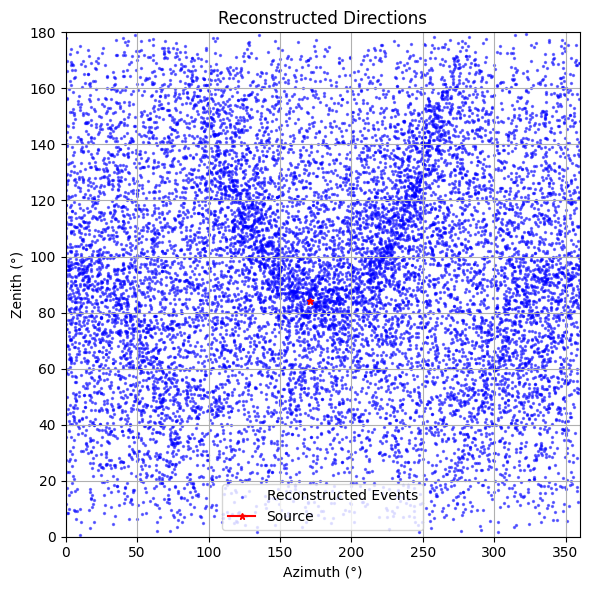


--- Signal Injection Summary ---
Total original events:      1008510
Simulated (injected) events: 14194 (1.41%)
Original events kept:        994316 (98.59%)
Combined total events:       1008510

--- Preview of 5 Random Combined Events ---
[368130] Time: 1695950167.43, Energy: 26.28, Zenith: 2.11, Azimuth: 1.26
[172143] Time: 1694902433.40, Energy: 2.34, Zenith: 1.55, Azimuth: 2.03
[162736] Time: 1694857384.45, Energy: 2.97, Zenith: 2.17, Azimuth: 5.81
[499532] Time: 1696586047.73, Energy: nan, Zenith: nan, Azimuth: nan
[388893] Time: 1696061802.67, Energy: 926.40, Zenith: 2.26, Azimuth: 5.68


In [127]:
from astropy.coordinates import SkyCoord, EarthLocation
from h5py import File
from km3astro.frame import get_location
#from km3astro.coordinates import get_location
source_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5"
# Load skycoord from file as you described
with File(source_file, 'r') as f:
    ra = f['skycoord/ra'][()]
    dec = f['skycoord/dec'][()]
    skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)

# Detector location
detector_location = get_location('orca')
from h5py import File
from astropy.table import Table

input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_30929077events.hdf5"
input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4982323events.hdf5"
#input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_7923events.hdf5"
input_file = "/home/wecapstor3/capn/capn107h/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4982323events_mc.hdf5"

input_file = "/home/wecapstor3/capn/capn107h/combined_eventlists/orca_KM3NeT_00000148_0001_combined_1008510events_mc.hdf5"
with File(input_file, 'r') as h5_file:
        eventList = Table.read(h5_file)

injected_energies = df_combined['reco_energy']
injected_reco_types = df_combined['type']
    
combine_times, combined_energies, combined_zeniths, combined_azimuths = inject_signal_times(
    time=eventList['time'].value.astype(float),
    energy=eventList['energy'].value.astype(float),
    zenith=eventList['zenith'],
    azimuth=eventList['azimuth'],
    reco_energies_to_inject=injected_energies,
    reco_types_to_inject = injected_reco_types,
    bin_time=1e-5,
    pulseshape='mvm',
    frequency=11,
    baseline=0.0,
    a=1.0,
    phi=0.0,
    method='base',
    kappa=5.0,
    skycoord=skycoord,
    detector_location=detector_location,
    track_resolution_func = fit_func_tr,
    shower_resolution_func = fit_func_sh,
    plot=True
)


4982323


In [ ]:
def create_binned_light_curve(times, bin_size_seconds=60):
    """Plot a binned light curve for the given event times."""
    if len(times) == 0:
        print("No events to plot.")
        return
    
    start_time, end_time = np.min(times), np.max(times) 
    num_bins = int((end_time - start_time) / bin_size_seconds)
    
    event_counts, bin_edges = np.histogram(times, bins=num_bins, range=(start_time, end_time))
    bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
    
    return bin_centers, event_counts

def plot_data_comparison(original_times, injected_signal_times, frequency, num_cycles=5, bin_size_seconds = None):
    """
    Plots a comparison between the initial dataset and the injected light curve.
    
    Parameters:
        lc_initial : Lightcurve
            Light curve of the original data before injection.
        lc_injected : Lightcurve
            Light curve of the dataset after injection.
        frequency : float
            The frequency of the signal (used to calculate the period).
        num_cycles : int, optional
            Number of signal periods to display (default is 5).
    """
    plt.figure(figsize=(10, 5))

    
    
    # Calculate period from frequency
    period = 1 / frequency  # Period of the signal
    if bin_size_seconds == None: bin_size_seconds = period/20.0

    # Define the time range to plot
    t_min = np.min([original_times[0],injected_signal_times[0]]) + period
    t_max = t_min + (num_cycles + 2) * period

    

    original_times_bin_centers, original_event_counts = create_binned_light_curve(original_times,bin_size_seconds=bin_size_seconds)
    injected_signal_bin_centers, injected_signal_counts = create_binned_light_curve(injected_signal_times,bin_size_seconds=bin_size_seconds)

    

    # Plot both initial and injected light curves within the specified time range
    plt.plot(original_times_bin_centers, original_event_counts, drawstyle='steps-mid', lw=4, label="Original Data", color='darkorange', alpha=1)
    plt.plot(injected_signal_bin_centers, injected_signal_counts, drawstyle='steps-mid', lw=2, label="Injected Data", color='darkblue', alpha=1)
    
    plt.xlabel("Time (s)")
    plt.ylabel("Intensity")
    plt.title(f"Initial vs Injected Light Curve ({num_cycles} cycles - {frequency:.2e} Hz - Rate {rate} 1/d)")
    plt.xlim([t_min+0.5*period,t_max-1.5*period])
    plt.legend()
    plt.grid(alpha=0.5)

plot_data_comparison(event_times, combined_times, 11)

: 

In [128]:

from astropy.timeseries import TimeSeries

TimeEventList= TimeSeries(time=Time(combine_times, format='unix'))
InjectedEventList = eventList.copy()
InjectedEventList['time'] = TimeEventList['time']
InjectedEventList['energy'] = combined_energies #* EventList['energy'].unit
InjectedEventList['zenith'] = combined_zeniths
InjectedEventList['azimuth'] = combined_azimuths

#### outdated: Sampling of new source direction based on the estimated angular resolution

In [47]:
from astropy.coordinates import EarthLocation
from astropy.time import Time
from h5py import File

source_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5"

#detector_location = EarthLocation(lat=36.27*u.deg, lon=16.1*u.deg, height=-2500*u.m)
detector_location = get_location('arca')
observation_time = Time(1650000000.0, format='unix')

with File(source_file, 'r') as f:
        source_name = f['source_name'][()].decode('utf-8')
        print("Source Name:", source_name)

        # SkyCoord information
        ra = f['skycoord/ra'][()]
        dec = f['skycoord/dec'][()]
        skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
        print("SkyCoord:", skycoord)

    

reco_dirs = sample_reco_directions_from_source_skycoord(
    source_coord=skycoord,
    reco_energies=combined_energies,
    resolution_func=lambda e: 0.5,  # 5 deg for now
    detector_location=detector_location,
    observation_time=observation_time
)

Source Name: Vela_X-1
SkyCoord: <SkyCoord (ICRS): (ra, dec) in deg
    (135.5286, -40.5547)>


/tmp/ipykernel_3510727/1945550024.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/hpc/capn/capn107h/software/km3astrovenv3.9.12/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


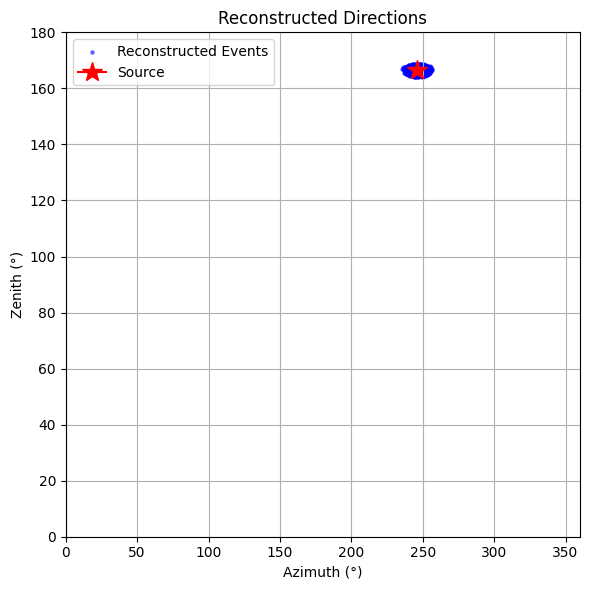

In [162]:
import matplotlib.pyplot as plt

def plot_reco_directions(result, title="Reconstructed Directions"):
    zen = result['zenith']
    az = result['azimuth']
    zen_true = result['zenith_true'][0]
    az_true = result['azimuth_true'][0]

    fig, ax = plt.subplots(figsize=(6, 6))
    sc = ax.scatter(az, zen, s=5, alpha=0.5, label='Reconstructed Events', color='blue')
    ax.plot(az_true, zen_true, marker='*', color='red', markersize=15, label='Source')

    ax.set_xlim(0, 360)
    ax.set_ylim(0, 180)
    ax.set_xlabel("Azimuth (°)")
    ax.set_ylabel("Zenith (°)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    plt.show()

plot_reco_directions(reco_dirs)

### Apply Selection Cuts 

In [129]:
import km3io.definitions as kd

def apply_selection_cuts(event_list, detector, energy_min, energy_max, nhits_tr_min,
                         nhits_sh_min, lik_tr_min, lik_sh_min, beta0_tr_max,
                         zenith_min, trackscore_low_max, trackscore_high_min):
    """Apply a set of selection cuts to a KM3NeT event list."""

    # Energy cut
    energy_mask = (event_list['energy'].value >= energy_min) & (event_list['energy'].value <= energy_max)
    event_list = event_list[energy_mask]

    # Track/Shower event selection
    track_events = (event_list['rec_type'] == kd.reconstruction.JPP_RECONSTRUCTION_TYPE) & \
                   (event_list['rec_stage'] == kd.reconstruction.JMUONBEGIN)

    if detector == 'arca':
        shower_events = (event_list['rec_type'] == kd.reconstruction.AANET_RECONSTRUCTION_TYPE) & \
                        (event_list['rec_stage'] == kd.reconstruction.AASHOWERBEGIN)
        hits_mask_shower = shower_events & (event_list['AASHOWERFIT_NUMBER_OF_HITS'] >= nhits_sh_min)
    elif detector == 'orca':
        shower_events = (event_list['rec_type'] == kd.reconstruction.JPP_RECONSTRUCTION_TYPE) & \
                        (event_list['rec_stage'] == kd.reconstruction.JSHOWERBEGIN)
        hits_mask_shower = shower_events & (event_list['JGANDALF_NUMBER_OF_HITS'] >= nhits_sh_min)
    else:
        raise ValueError(f"Unsupported detector: {detector}")

    # Hits cut
    hits_mask_track = track_events & (event_list['JGANDALF_NUMBER_OF_HITS'] >= nhits_tr_min)
    event_list = event_list[hits_mask_shower | hits_mask_track]

    # Re-derive events post hits cut
    track_events = (event_list['rec_type'] == kd.reconstruction.JPP_RECONSTRUCTION_TYPE) & \
                   (event_list['rec_stage'] == kd.reconstruction.JMUONBEGIN)
    shower_events = (event_list['rec_type'] == kd.reconstruction.AANET_RECONSTRUCTION_TYPE) & \
                    (event_list['rec_stage'] == kd.reconstruction.AASHOWERBEGIN) if detector == 'arca' else \
                    (event_list['rec_type'] == kd.reconstruction.JPP_RECONSTRUCTION_TYPE) & \
                    (event_list['rec_stage'] == kd.reconstruction.JSHOWERBEGIN)

    # Likelihood cut
    lik_mask_track = track_events & (np.abs(event_list['likelihood']) >= lik_tr_min)
    lik_mask_shower = shower_events & (np.abs(event_list['likelihood']) >= lik_sh_min)
    event_list = event_list[lik_mask_track | lik_mask_shower]

    # Zenith cut
    zenith_min_rad = zenith_min * np.pi / 180
    event_list = event_list[event_list['zenith'] >= zenith_min_rad]

    # Beta0 cut (only applies to tracks)
    track_events = (event_list['rec_type'] == kd.reconstruction.JPP_RECONSTRUCTION_TYPE) & \
                   (event_list['rec_stage'] == kd.reconstruction.JMUONBEGIN)
    shower_events = (event_list['rec_type'] == kd.reconstruction.AANET_RECONSTRUCTION_TYPE) & \
                    (event_list['rec_stage'] == kd.reconstruction.AASHOWERBEGIN) if detector == 'arca' else \
                    (event_list['rec_type'] == kd.reconstruction.JPP_RECONSTRUCTION_TYPE) & \
                    (event_list['rec_stage'] == kd.reconstruction.JSHOWERBEGIN)
    beta0_tr_mask = track_events & (event_list['JGANDALF_BETA0_RAD'] <= beta0_tr_max)
    event_list = event_list[beta0_tr_mask | shower_events]

    # Trackscore cut
    trackscore_mask = (event_list['track_score'] <= trackscore_low_max) | \
                      (event_list['track_score'] >= trackscore_high_min)
    event_list = event_list[trackscore_mask]

    return event_list


In [49]:
cut_params = {
                'detector': str(arguments['--detector']),
                'energy_min': float(arguments['--energy_min']),
                'energy_max': float(arguments['--energy_max']),
                'nhits_tr_min': float(arguments['--nhits_tr_min']),
                'nhits_sh_min': float(arguments['--nhits_sh_min']),
                'lik_tr_min': float(arguments['--lik_tr_min']),
                'lik_sh_min': float(arguments['--lik_sh_min']),
                'beta0_tr_max': float(arguments['--beta0_tr_max']),
                'zenith_min': float(arguments['--zenith_min']),
                'trackscore_low_max': float(arguments['--trackscore_low_max']),
                'trackscore_high_min': float(arguments['--trackscore_high_min']),
            }

NameError: name 'arguments' is not defined

In [131]:
cut_params = {
                'detector': 'arca',
                'energy_min': 1e2,
                'energy_max': 1e8,
                'nhits_tr_min': 20,
                'nhits_sh_min': 20,
                'lik_tr_min': 50.,
                'lik_sh_min': 50.,
                'beta0_tr_max': 1,
                'zenith_min': 0,
                'trackscore_low_max': 0.5,
                'trackscore_high_min': 0.5,
            }
InjectedEventListWithCuts = InjectedEventList
print(f"No cuts applied.")
#InjectedEventListWithCuts = apply_selection_cuts(InjectedEventList, **cut_params)
#print(f"All cuts applied.")

No cuts applied.


In [166]:
len(InjectedEventListWithCuts['time'])

2340595

### Select Subsets

In [132]:
def extract_subset_within_gtis(event_list, gti_array, desired_length_days):
    """Extract a time-limited subset from event_list, using GTIs to accumulate real live-time."""
    subset_event_indices = []
    accumulated_live_time = 0.0
    used_gtis = []

    event_times = event_list['time']

    if gti_array is not None:
        for start, stop in gti_array:
            gti_duration = stop - start

            if accumulated_live_time + gti_duration > desired_length_days:
                remaining_time = desired_length_days - accumulated_live_time
                new_stop = start + remaining_time
                in_partial_gti = (event_times.value >= start) & (event_times.value < new_stop)
                selected = np.where(in_partial_gti)[0]
                subset_event_indices.extend(selected.tolist())
                used_gtis.append([start, new_stop])
                accumulated_live_time += remaining_time
                break
            else:
                in_gti = (event_times.value >= start) & (event_times.value <= stop)
                selected = np.where(in_gti)[0]
                subset_event_indices.extend(selected.tolist())
                used_gtis.append([start, stop])
                accumulated_live_time += gti_duration

            if accumulated_live_time >= desired_length_days:
                break
    else:
        first_time = event_times[0]
        last_time = first_time + desired_length_days
        in_range = (event_times >= first_time) & (event_times < last_time)
        subset_event_indices = np.where(in_range)[0].tolist()
        used_gtis = [[first_time.value, last_time.value]]
        accumulated_live_time = desired_length_days

    subset = event_list[subset_event_indices]
    return subset, accumulated_live_time, np.array(used_gtis)

event_times = InjectedEventListWithCuts['time']
current_gti = None

print("event_times[:10]: ", event_times[:10])
#print("current_gti[:3]: ", current_gti[:3])


# Apply GTI filtering mask as safety check
if current_gti is not None:
    mask = np.zeros_like(event_times, dtype=bool)
    for start, stop in current_gti:
        in_gti = (event_times.value >= start) & (event_times.value <= stop)
        mask |= in_gti
    filtered_events = InjectedEventListWithCuts[mask]
    filtered_times = event_times[mask]
else:
    filtered_events = InjectedEventListWithCuts
    filtered_times = event_times

print("filtered_times[:10]: ", filtered_times[:10])


# Compute total active time
if current_gti is not None:
    total_active_time = np.sum(current_gti[:, 1] - current_gti[:, 0])
else:
    total_active_time = filtered_times[-1] - filtered_times[0] # This messes up, not calculating time in seconds

total_active_time = event_times[-1].value - event_times[0].value
length = 60
desired_length = length#* 24.0*3600.0

total_active_time_days = total_active_time / (3600.0*24.0)
print(f"Total Active Time: {total_active_time} s - {total_active_time_days} days")
print(f"Chosen Length: {desired_length} s - {desired_length/(24.0*3600.0)} d")
print(f"Number of Events: {len(event_times)}")

event_times[:10]:  [1.69404480e+09 1.69404481e+09 1.69404481e+09 1.69404481e+09
 1.69404481e+09 1.69404482e+09 1.69404482e+09 1.69404483e+09
 1.69404483e+09 1.69404483e+09]
filtered_times[:10]:  [1.69404480e+09 1.69404481e+09 1.69404481e+09 1.69404481e+09
 1.69404481e+09 1.69404482e+09 1.69404482e+09 1.69404483e+09
 1.69404483e+09 1.69404483e+09]
Total Active Time: 4946394.0984938145 s - 57.24993169553026 days
Chosen Length: 60 s - 0.0006944444444444445 d
Number of Events: 1008510


In [133]:
# Extract the GTI-respecting subset
InjectedEventListWithCutsSubset, used_live_time, used_gtis = extract_subset_within_gtis(InjectedEventListWithCuts, current_gti, desired_length)

used_live_time_seconds = used_live_time *(24.0*3600.0)
print(f"New Amount of Events for {used_live_time:.2f} days ({used_live_time_seconds:.2f} s): {len(InjectedEventListWithCutsSubset['time'])}")

InjectedEventListWithCutsSubset.meta['length'] = length

/home/hpc/capn/capn107h/software/km3astrovenv3.9.12/lib/python3.9/site-packages/astropy/time/core.py:2952: TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
  warn(


New Amount of Events for 60.00 days (5184000.00 s): 1008510


### Applying Epoch Folding

Times: [1.69404480e+09 1.69404481e+09 1.69404481e+09 ... 1.69899120e+09
 1.69899120e+09 1.69899120e+09]
First 10 Times: ['1694044804.899', '1694044809.054', '1694044809.751', '1694044810.252', '1694044811.206', '1694044817.822', '1694044819.251', '1694044827.276', '1694044827.339', '1694044828.815']
Last 10 Times: ['1698991153.581', '1698991155.936', '1698991159.757', '1698991165.184', '1698991174.495', '1698991189.156', '1698991189.157', '1698991196.143', '1698991196.166', '1698991198.997']
Number of available events: 1008510
Test frequencies: [10.9999975  10.9999975  10.99999751 ... 11.00000249 11.0000025
 11.0000025 ]
nbins: 32
Stingray version: 2.2
epoch_folding_search is defined in: /home/hpc/capn/capn107h/software/km3astrovenv3.9.12/lib/python3.9/site-packages/stingray/pulse/search.py


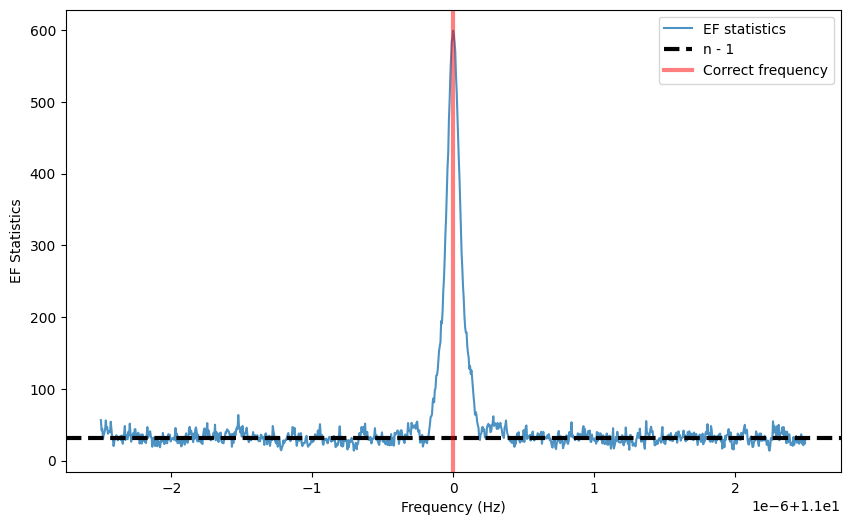

In [134]:
from stingray.pulse.search import epoch_folding_search, z_n_search, search_best_peaks
from epochfolding.stingray_epochfolding import savehdf5, get_testfrequencies
import stingray
import inspect
nbin = 32

FinalEventList= TimeSeries(time=Time(InjectedEventListWithCutsSubset['time'], format='unix'))

print(f"Times: {np.array(FinalEventList['time'].value)}")
frequencies = get_testfrequencies(11,1000, 5e-9)

print(f"First 10 Times: {[f'{x:.3f}' for x in np.array(FinalEventList['time'].value)[:10]]}")
print(f"Last 10 Times: {[f'{x:.3f}' for x in np.array(FinalEventList['time'].value)[-10:]]}")
print(f"Number of available events: {len(np.array(FinalEventList['time'].value))}")
print(f"Test frequencies: {frequencies}")
print(f"nbins: {nbin}")

freq, efstat = epoch_folding_search(
    np.array(FinalEventList['time'].value),
    frequencies,
    nbin=nbin,
    segment_size=1e10,
    gti=used_gtis
) 

#output_file_ef = output_file + f"I{data['iteration'].zfill(4)}_{fequency}Hz_ef.hdf5"
#output_plot_ef = output_file + f"I{data['iteration'].zfill(4)}_{frequency}Hz_efplot.png"

#if plot is True:
plt.figure()
plt.plot(freq, efstat, label='EF statistics', alpha=0.8)
plt.axhline(nbin- 1, ls='--', lw=3, color='k', label='n - 1')
plt.axvline(11, lw=3, alpha=0.5, color='r', label='Correct frequency')
plt.xlabel('Frequency (Hz)')
plt.ylabel('EF Statistics')
_ = plt.legend()

threshold = (np.max(efstat)*0.1+nbin - 1)
best_x, best_y = search_best_peaks(freq,efstat,threshold)
y_min, y_max = plt.ylim()
offset = 0.04 * (y_max - y_min)

'''
for i, (x_value, y_value) in enumerate(zip(best_x, best_y)):
    label = 'peaks' if i == 0 else None  # Label only the first line
    plt.axvline(x_value, ls='dotted', lw=2, color='k', label=label)

    # Annotate the peak with its y-value slightly to the righ
    #plt.text(x_value + 0.03e-5, y_value, f"{y_value:.2f}", color='darkorange', fontsize=10)
    plt.text(x_value + 0.03e-5, y_value, f"{x_value:.4e}", color='darkorange', fontsize=10)
    plt.text(x_value + 0.03e-5, y_value-offset, f"{(float(data['frequency'])/x_value):.2f}", color='darkorange', fontsize=10)
'''
#plt.savefig(output_plot_ef)

#print(f"Plot saved: {output_plot_ef}")

print(f"Stingray version: {stingray.__version__}")
print(f"epoch_folding_search is defined in: {inspect.getfile(epoch_folding_search)}")

#with h5py.File(output_file_ef, 'w') as out:
#    savehdf5(freq, efstat, out)